In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path("/Users/manishkavuri/Desktop/nba-lineup-decision-engine")

FACT_STINTS_PATH = PROJECT_ROOT / "data/processed/final/fact_lineup_stints_v2_2024_25.parquet"
TEAM_FEATURES_PATH = PROJECT_ROOT / "data/processed/final/team_lineup_stint_features_v1_2024_25.parquet"
RAW_PBP_DIR = PROJECT_ROOT / "data/raw/pbp"

fact_stints = pd.read_parquet(FACT_STINTS_PATH)
team_features = pd.read_parquet(TEAM_FEATURES_PATH)

print("Fact stints:", fact_stints.shape)
print("Team features v1:", team_features.shape)
print("Games:", fact_stints["game_id"].nunique())

Fact stints: (40768, 25)
Team features v1: (81536, 36)
Games: 1230


In [2]:
fact_stints = fact_stints.copy()

fact_stints = fact_stints.sort_values(
    ["game_id", "period", "start_seconds_remaining"],
    ascending=[True, True, False]
).reset_index(drop=True)

fact_stints["stint_number"] = fact_stints.groupby("game_id").cumcount() + 1

fact_stints["stint_id"] = (
    fact_stints["game_id"].astype(str)
    + "_"
    + fact_stints["stint_number"].astype(str).str.zfill(3)
)

print(fact_stints[["game_id", "stint_id", "period", "start_clock", "end_clock"]].head())

      game_id        stint_id  period  start_clock    end_clock
0  0022400001  0022400001_001       1  PT12M00.00S  PT07M02.00S
1  0022400001  0022400001_002       1  PT07M02.00S  PT05M57.00S
2  0022400001  0022400001_003       1  PT05M57.00S  PT04M51.00S
3  0022400001  0022400001_004       1  PT04M51.00S  PT04M27.00S
4  0022400001  0022400001_005       1  PT04M27.00S  PT00M26.30S


In [3]:
def parse_clock_seconds_remaining(clock):
    """
    Parse NBA ISO-style clock, e.g. PT11M43.00S -> seconds remaining.
    """
    if pd.isna(clock):
        return np.nan

    s = str(clock)

    m = re.search(r"PT(?:(\d+)M)?(?:(\d+(?:\.\d+)?)S)?", s)

    if not m:
        return np.nan

    minutes = float(m.group(1)) if m.group(1) is not None else 0.0
    seconds = float(m.group(2)) if m.group(2) is not None else 0.0

    return minutes * 60 + seconds


def load_pbp_df(game_id):
    """
    Load one raw PBP JSON into a dataframe.
    """
    game_id = str(game_id).zfill(10)
    path = RAW_PBP_DIR / f"{game_id}.json"

    with open(path, "r") as f:
        raw = json.load(f)

    actions = raw["game"]["actions"]
    pbp = pd.DataFrame(actions)

    pbp["game_id"] = game_id
    pbp["period"] = pd.to_numeric(pbp["period"], errors="coerce").astype("Int64")
    pbp["team_id"] = pd.to_numeric(pbp.get("teamId"), errors="coerce")
    pbp["clock_seconds_remaining"] = pbp["clock"].apply(parse_clock_seconds_remaining)

    pbp["actionType_clean"] = pbp["actionType"].astype(str).str.lower().str.strip()
    pbp["subType_clean"] = pbp["subType"].astype(str).str.lower().str.strip()
    pbp["shotResult_clean"] = pbp.get("shotResult", "").astype(str).str.lower().str.strip()

    pbp = pbp.sort_values(["period", "clock_seconds_remaining", "actionNumber"], ascending=[True, False, True])

    return pbp


def assign_events_to_stints(pbp, game_stints):
    """
    Assign each PBP event to a lineup stint based on period and clock.
    We ignore zero-duration stints because they do not represent actual gameplay time.
    """
    pbp = pbp.copy()
    game_stints = game_stints[game_stints["duration_seconds"] > 0].copy()

    pbp["stint_id"] = None

    for period, events_p in pbp.groupby("period"):
        stints_p = game_stints[game_stints["period"] == int(period)].copy()

        if stints_p.empty:
            continue

        for idx, event in events_p.iterrows():
            sec = event["clock_seconds_remaining"]

            possible = stints_p[
                (stints_p["start_seconds_remaining"] >= sec)
                & (stints_p["end_seconds_remaining"] <= sec)
            ]

            if not possible.empty:
                pbp.loc[idx, "stint_id"] = possible.iloc[0]["stint_id"]

    return pbp

In [4]:
def add_event_indicators(pbp):
    pbp = pbp.copy()

    at = pbp["actionType_clean"]
    st = pbp["subType_clean"]
    sr = pbp["shotResult_clean"]

    # Shot attempts
    pbp["fga"] = ((at.isin(["2pt", "3pt"])) & (pd.to_numeric(pbp.get("isFieldGoal"), errors="coerce") == 1)).astype(int)
    pbp["fgm"] = ((pbp["fga"] == 1) & (sr == "made")).astype(int)

    pbp["fg3a"] = ((at == "3pt") & (pd.to_numeric(pbp.get("isFieldGoal"), errors="coerce") == 1)).astype(int)
    pbp["fg3m"] = ((pbp["fg3a"] == 1) & (sr == "made")).astype(int)

    # Free throws
    pbp["fta"] = (at == "freethrow").astype(int)
    pbp["ftm"] = ((pbp["fta"] == 1) & (sr == "made")).astype(int)

    # Turnovers
    pbp["tov"] = (at == "turnover").astype(int)

    # Rebounds
    pbp["oreb"] = ((at == "rebound") & (st == "offensive")).astype(int)
    pbp["dreb"] = ((at == "rebound") & (st == "defensive")).astype(int)

    # Other box score events
    pbp["ast"] = (
        (pbp["fgm"] == 1)
        & (pd.to_numeric(pbp.get("assistPersonId"), errors="coerce").notna())
    ).astype(int)

    pbp["stl"] = (at == "steal").astype(int)
    pbp["blk"] = (at == "block").astype(int)
    pbp["foul"] = (at == "foul").astype(int)

    return pbp

In [5]:
def build_event_stats_for_game(game_id, fact_stints):
    game_id = str(game_id).zfill(10)

    game_stints = fact_stints[fact_stints["game_id"].astype(str).str.zfill(10) == game_id].copy()

    pbp = load_pbp_df(game_id)
    pbp = assign_events_to_stints(pbp, game_stints)
    pbp = add_event_indicators(pbp)

    # Keep only events assigned to a real stint and a real team
    pbp_stats = pbp[
        (pbp["stint_id"].notna())
        & (pbp["team_id"].notna())
    ].copy()

    stat_cols = [
        "fga", "fgm", "fg3a", "fg3m",
        "fta", "ftm", "tov",
        "oreb", "dreb",
        "ast", "stl", "blk", "foul"
    ]

    out = (
        pbp_stats
        .groupby(["stint_id", "team_id"])[stat_cols]
        .sum()
        .reset_index()
    )

    out["team_id"] = out["team_id"].astype(int)

    return out


one_game_stats = build_event_stats_for_game("0022400001", fact_stints)

display(one_game_stats.head())
print(one_game_stats.shape)

,stint_id,team_id,fga,fgm,fg3a,fg3m,fta,ftm,tov,oreb,dreb,ast,stl,blk,foul
0,0022400001_001,1610612737,13,5,4,1,4,0,2,8,5,4,2,0,1
1,0022400001_001,1610612738,9,3,7,1,2,1,2,2,4,3,1,1,3
2,0022400001_002,1610612737,3,0,0,0,0,0,0,2,0,0,0,0,1
3,0022400001_002,1610612738,2,1,0,0,2,2,0,1,1,1,0,0,0
4,0022400001_003,1610612737,2,1,1,0,0,0,0,0,0,1,1,0,1


(58, 15)


In [6]:
all_game_ids = sorted(fact_stints["game_id"].astype(str).str.zfill(10).unique())

all_event_stats = []
errors = []

for i, game_id in enumerate(all_game_ids, start=1):
    if i % 100 == 0:
        print(f"Processing {i}/{len(all_game_ids)}")

    try:
        game_stats = build_event_stats_for_game(game_id, fact_stints)
        all_event_stats.append(game_stats)

    except Exception as e:
        print(f"FAILED {game_id}: {e}")
        errors.append({"game_id": game_id, "error": str(e)})

event_stats = pd.concat(all_event_stats, ignore_index=True)

print("Event stats shape:", event_stats.shape)
print("Failed games:", len(errors))

display(event_stats.head())

event_errors = pd.DataFrame(errors)
display(event_errors.head())

Processing 100/1230
Processing 200/1230
Processing 300/1230
Processing 400/1230
Processing 500/1230
Processing 600/1230
Processing 700/1230
Processing 800/1230
Processing 900/1230
Processing 1000/1230
Processing 1100/1230
Processing 1200/1230
Event stats shape: (72814, 15)
Failed games: 0


,stint_id,team_id,fga,fgm,fg3a,fg3m,fta,ftm,tov,oreb,dreb,ast,stl,blk,foul
0,0022400001_001,1610612737,13,5,4,1,4,0,2,8,5,4,2,0,1
1,0022400001_001,1610612738,9,3,7,1,2,1,2,2,4,3,1,1,3
2,0022400001_002,1610612737,3,0,0,0,0,0,0,2,0,0,0,0,1
3,0022400001_002,1610612738,2,1,0,0,2,2,0,1,1,1,0,0,0
4,0022400001_003,1610612737,2,1,1,0,0,0,0,0,0,1,1,0,1


""


In [7]:
team_v2 = team_features.copy()

team_v2["team_id"] = team_v2["team_id"].astype(int)
team_v2["opponent_team_id"] = team_v2["opponent_team_id"].astype(int)

event_stats_team = event_stats.copy()
event_stats_team["team_id"] = event_stats_team["team_id"].astype(int)

# Merge offensive/team stats
team_v2 = team_v2.merge(
    event_stats_team,
    on=["stint_id", "team_id"],
    how="left"
)

stat_cols = [
    "fga", "fgm", "fg3a", "fg3m",
    "fta", "ftm", "tov",
    "oreb", "dreb",
    "ast", "stl", "blk", "foul"
]

for col in stat_cols:
    team_v2[col] = team_v2[col].fillna(0)

# Merge opponent stats
opp_stats = event_stats_team.rename(
    columns={
        "team_id": "opponent_team_id",
        **{col: f"opp_{col}" for col in stat_cols}
    }
)

team_v2 = team_v2.merge(
    opp_stats,
    on=["stint_id", "opponent_team_id"],
    how="left"
)

for col in [f"opp_{c}" for c in stat_cols]:
    team_v2[col] = team_v2[col].fillna(0)

print(team_v2.shape)
display(team_v2.head())

(81536, 62)


,stint_id,game_id,stint_number,period,is_overtime,start_clock,end_clock,start_seconds_remaining,end_seconds_remaining,duration_seconds,...,opp_fg3m,opp_fta,opp_ftm,opp_tov,opp_oreb,opp_dreb,opp_ast,opp_stl,opp_blk,opp_foul
0,0022400001_001,0022400001,1,1,False,PT12M00.00S,PT07M02.00S,720.0,422.0,298.0,...,1.0,4.0,0.0,2.0,8.0,5.0,4.0,2.0,0.0,1.0
1,0022400001_002,0022400001,2,1,False,PT07M02.00S,PT05M57.00S,422.0,357.0,65.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0
2,0022400001_003,0022400001,3,1,False,PT05M57.00S,PT04M51.00S,357.0,291.0,66.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
3,0022400001_004,0022400001,4,1,False,PT04M51.00S,PT04M27.00S,291.0,267.0,24.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0022400001_005,0022400001,5,1,False,PT04M27.00S,PT00M26.30S,267.0,26.3,240.7,...,1.0,2.0,2.0,3.0,0.0,3.0,5.0,1.0,0.0,3.0


In [8]:
def safe_divide(num, denom):
    return np.where(denom > 0, num / denom, np.nan)


# Estimated possessions using common basketball formula
team_v2["possessions_est"] = (
    team_v2["fga"]
    + 0.44 * team_v2["fta"]
    + team_v2["tov"]
    - team_v2["oreb"]
)

team_v2["opp_possessions_est"] = (
    team_v2["opp_fga"]
    + 0.44 * team_v2["opp_fta"]
    + team_v2["opp_tov"]
    - team_v2["opp_oreb"]
)

# Avoid weird negative estimates on tiny stints
team_v2["possessions_est"] = team_v2["possessions_est"].clip(lower=0)
team_v2["opp_possessions_est"] = team_v2["opp_possessions_est"].clip(lower=0)

# Efficiency metrics
team_v2["points_per_possession"] = safe_divide(
    team_v2["points_for"],
    team_v2["possessions_est"]
)

team_v2["opp_points_per_possession"] = safe_divide(
    team_v2["points_against"],
    team_v2["opp_possessions_est"]
)

team_v2["offensive_rating"] = 100 * team_v2["points_per_possession"]
team_v2["defensive_rating"] = 100 * team_v2["opp_points_per_possession"]
team_v2["net_rating"] = team_v2["offensive_rating"] - team_v2["defensive_rating"]

# Shooting / style stats
team_v2["efg_pct"] = safe_divide(
    team_v2["fgm"] + 0.5 * team_v2["fg3m"],
    team_v2["fga"]
)

team_v2["three_point_attempt_rate"] = safe_divide(
    team_v2["fg3a"],
    team_v2["fga"]
)

team_v2["free_throw_rate"] = safe_divide(
    team_v2["fta"],
    team_v2["fga"]
)

team_v2["turnover_rate"] = safe_divide(
    team_v2["tov"],
    team_v2["possessions_est"]
)

team_v2["offensive_rebound_rate"] = safe_divide(
    team_v2["oreb"],
    team_v2["oreb"] + team_v2["opp_dreb"]
)

team_v2["assist_rate"] = safe_divide(
    team_v2["ast"],
    team_v2["fgm"]
)

display(
    team_v2[
        [
            "stint_id",
            "team_id",
            "duration_seconds",
            "points_for",
            "points_against",
            "possessions_est",
            "opp_possessions_est",
            "offensive_rating",
            "defensive_rating",
            "net_rating",
            "efg_pct",
            "turnover_rate",
        ]
    ].head(20)
)

,stint_id,team_id,duration_seconds,points_for,points_against,possessions_est,opp_possessions_est,offensive_rating,defensive_rating,net_rating,efg_pct,turnover_rate
0,0022400001_001,1610612738,298.0,8,11,9.88,8.76,80.971660,125.570776,-44.599116,0.388889,0.202429
1,0022400001_002,1610612738,65.0,4,0,1.88,1.00,212.765957,0.000000,212.765957,0.500000,0.000000
2,0022400001_003,1610612738,66.0,2,2,1.88,2.00,106.382979,100.000000,6.382979,NaN,0.531915
3,0022400001_004,1610612738,24.0,0,3,0.00,1.44,NaN,208.333333,NaN,NaN,NaN
4,0022400001_005,1610612738,240.7,14,13,10.32,9.88,135.658915,131.578947,4.079967,0.611111,0.096899
5,0022400001_006,1610612738,26.3,3,0,1.00,0.00,300.000000,NaN,NaN,1.500000,0.000000
6,0022400001_007,1610612738,0.0,0,0,0.00,0.00,NaN,NaN,NaN,NaN,NaN
7,0022400001_008,1610612738,125.0,6,2,4.00,4.00,150.000000,50.000000,100.000000,1.000000,0.250000
8,0022400001_009,1610612738,134.0,4,7,4.88,4.00,81.967213,175.000000,-93.032787,0.250000,0.000000
9,0022400001_010,1610612738,55.0,0,0,1.00,2.00,0.000000,0.000000,0.000000,0.000000,0.000000


In [9]:
rating_cols = [
    "possessions_est",
    "opp_possessions_est",
    "offensive_rating",
    "defensive_rating",
    "net_rating",
    "efg_pct",
    "turnover_rate",
]

missing_summary = (
    team_v2[rating_cols]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

missing_summary.columns = ["column", "missing_rate"]

display(missing_summary)

,column,missing_rate
0,net_rating,0.225103
1,efg_pct,0.218640
2,offensive_rating,0.176719
3,defensive_rating,0.176719
4,turnover_rate,0.176719
5,possessions_est,0.000000
6,opp_possessions_est,0.000000


In [10]:
model_v2 = team_v2[
    (team_v2["duration_seconds"] >= 30)
    & (team_v2["possessions_est"] >= 1)
    & (team_v2["opp_possessions_est"] >= 1)
    & (team_v2["offensive_rating"].notna())
    & (team_v2["defensive_rating"].notna())
    & (team_v2["net_rating"].notna())
].copy()

print("Original:", team_v2.shape)
print("Model v2:", model_v2.shape)
print("Games:", model_v2["game_id"].nunique())
print("Lineups:", model_v2["lineup_key"].nunique())

display(
    model_v2[
        [
            "duration_seconds",
            "possessions_est",
            "opp_possessions_est",
            "offensive_rating",
            "defensive_rating",
            "net_rating",
            "efg_pct",
            "turnover_rate",
        ]
    ].describe()
)

Original: (81536, 75)
Model v2: (57086, 75)
Games: 1230
Lineups: 3274


,duration_seconds,possessions_est,opp_possessions_est,offensive_rating,defensive_rating,net_rating,efg_pct,turnover_rate
count,57086.000000,57086.000000,57086.000000,57086.000000,57086.000000,57086.000000,55669.000000,57086.000000
mean,118.308433,3.948925,3.948925,117.475753,117.475753,0.000000,0.560156,0.148584
std,77.775937,2.686535,2.686535,75.705914,75.705914,111.706475,0.393715,0.221272
min,30.000000,1.000000,1.000000,0.000000,0.000000,-600.000000,0.000000,0.000000
25%,63.000000,2.000000,2.000000,66.666667,66.666667,-69.186047,0.312500,0.000000
50%,96.000000,3.000000,3.000000,112.500000,112.500000,0.000000,0.500000,0.000000
75%,148.000000,5.000000,5.000000,166.666667,166.666667,69.186047,0.833333,0.250000
max,720.000000,26.200000,26.200000,600.000000,600.000000,600.000000,1.500000,1.136364


In [11]:
lineup_v2 = (
    model_v2
    .groupby(["team_id", "lineup_key"])
    .agg(
        total_minutes=("duration_minutes", "sum"),
        stints=("stint_id", "count"),
        games=("game_id", "nunique"),
        points_for=("points_for", "sum"),
        points_against=("points_against", "sum"),
        possessions=("possessions_est", "sum"),
        opp_possessions=("opp_possessions_est", "sum"),
        fga=("fga", "sum"),
        fgm=("fgm", "sum"),
        fg3a=("fg3a", "sum"),
        fg3m=("fg3m", "sum"),
        fta=("fta", "sum"),
        ftm=("ftm", "sum"),
        tov=("tov", "sum"),
        oreb=("oreb", "sum"),
        dreb=("dreb", "sum"),
    )
    .reset_index()
)

lineup_v2["offensive_rating"] = 100 * lineup_v2["points_for"] / lineup_v2["possessions"]
lineup_v2["defensive_rating"] = 100 * lineup_v2["points_against"] / lineup_v2["opp_possessions"]
lineup_v2["net_rating"] = lineup_v2["offensive_rating"] - lineup_v2["defensive_rating"]

lineup_v2["efg_pct"] = (
    lineup_v2["fgm"] + 0.5 * lineup_v2["fg3m"]
) / lineup_v2["fga"]

lineup_v2["turnover_rate"] = lineup_v2["tov"] / lineup_v2["possessions"]
lineup_v2["three_point_attempt_rate"] = lineup_v2["fg3a"] / lineup_v2["fga"]
lineup_v2["free_throw_rate"] = lineup_v2["fta"] / lineup_v2["fga"]

qualified_lineup_v2 = lineup_v2[
    (lineup_v2["total_minutes"] >= 50)
    & (lineup_v2["possessions"] >= 50)
    & (lineup_v2["opp_possessions"] >= 50)
].copy()

display(
    qualified_lineup_v2
    .sort_values("offensive_rating", ascending=False)
    .head(10)
)

display(
    qualified_lineup_v2
    .sort_values("net_rating", ascending=False)
    .head(10)
)

,team_id,lineup_key,total_minutes,stints,games,points_for,points_against,possessions,opp_possessions,fga,...,tov,oreb,dreb,offensive_rating,defensive_rating,net_rating,efg_pct,turnover_rate,three_point_attempt_rate,free_throw_rate
647,1610612743,201566-1627750-1629008-1631124-1631128,58.318333,26,5,175,143,115.92,119.88,113.0,...,8.0,24.0,44.0,150.966184,119.285953,31.680231,0.632743,0.069013,0.380531,0.380531
1007,1610612746,201587-202695-203992-1626181-1627732,70.716667,31,6,204,144,141.72,136.20,130.0,...,12.0,17.0,57.0,143.945809,105.726872,38.218936,0.657692,0.084674,0.392308,0.292308
135,1610612738,201143-201950-1627759-1628401-1628436,70.488333,30,5,192,153,133.56,135.24,130.0,...,14.0,21.0,52.0,143.755615,113.132209,30.623406,0.661538,0.104822,0.546154,0.184615
1378,1610612749,201572-203507-1626171-1627752-1628398,80.643333,40,3,225,188,156.88,159.92,149.0,...,15.0,30.0,58.0,143.421724,117.558779,25.862944,0.630872,0.095614,0.436242,0.348993
2264,1610612758,201942-1627734-1628368-1628370-1628989,67.830000,35,4,195,160,137.64,141.76,139.0,...,9.0,24.0,46.0,141.673932,112.866817,28.807115,0.597122,0.065388,0.345324,0.223022
2553,1610612761,1628449-1629628-1630193-1630534-1630567,71.245000,36,3,188,154,133.08,131.24,130.0,...,11.0,22.0,51.0,141.268410,117.342274,23.926136,0.626923,0.082657,0.407692,0.246154
1928,1610612755,200768-202331-202704-203954-1626162,57.031667,28,2,151,136,107.08,111.24,101.0,...,10.0,18.0,35.0,141.016063,122.258181,18.757882,0.618812,0.093388,0.485149,0.316832
2430,1610612760,1627936-1628392-1629026-1630198-1630598,57.801667,28,5,167,135,120.32,107.28,122.0,...,5.0,19.0,42.0,138.796543,125.838926,12.957616,0.594262,0.041556,0.327869,0.229508
774,1610612744,201939-203110-1626172-1627741-1627780,89.281667,49,5,234,224,168.92,171.12,173.0,...,19.0,42.0,49.0,138.527113,130.902291,7.624823,0.580925,0.112479,0.433526,0.248555
18,1610612737,1627777-1629027-1629611-1630168-1630249,56.750000,32,2,158,138,114.36,111.44,112.0,...,15.0,21.0,37.0,138.160196,123.833453,14.326743,0.633929,0.131165,0.464286,0.169643


,team_id,lineup_key,total_minutes,stints,games,points_for,points_against,possessions,opp_possessions,fga,...,tov,oreb,dreb,offensive_rating,defensive_rating,net_rating,efg_pct,turnover_rate,three_point_attempt_rate,free_throw_rate
1007,1610612746,201587-202695-203992-1626181-1627732,70.716667,31,6,204,144,141.72,136.20,130.0,...,12.0,17.0,57.0,143.945809,105.726872,38.218936,0.657692,0.084674,0.392308,0.292308
2482,1610612760,1628392-1629026-1630198-1630598-1631114,57.190000,30,5,139,97,116.84,115.92,120.0,...,11.0,19.0,53.0,118.966107,83.678399,35.287709,0.537500,0.094146,0.491667,0.091667
2496,1610612760,1628983-1629652-1631096-1631114-1641717,66.660000,31,6,187,135,145.92,144.76,135.0,...,12.0,9.0,56.0,128.152412,93.257806,34.894606,0.629630,0.082237,0.451852,0.133333
2459,1610612760,1628392-1628983-1629026-1629652-1630598,68.615000,34,6,200,151,147.96,149.44,130.0,...,22.0,19.0,60.0,135.171668,101.043897,34.127771,0.657692,0.148689,0.384615,0.261538
2453,1610612760,1627936-1629652-1630198-1630598-1631096,71.783333,34,6,171,121,149.80,146.96,154.0,...,17.0,30.0,66.0,114.152203,82.335329,31.816874,0.500000,0.113485,0.357143,0.129870
647,1610612743,201566-1627750-1629008-1631124-1631128,58.318333,26,5,175,143,115.92,119.88,113.0,...,8.0,24.0,44.0,150.966184,119.285953,31.680231,0.632743,0.069013,0.380531,0.380531
135,1610612738,201143-201950-1627759-1628401-1628436,70.488333,30,5,192,153,133.56,135.24,130.0,...,14.0,21.0,52.0,143.755615,113.132209,30.623406,0.661538,0.104822,0.546154,0.184615
2264,1610612758,201942-1627734-1628368-1628370-1628989,67.830000,35,4,195,160,137.64,141.76,139.0,...,9.0,24.0,46.0,141.673932,112.866817,28.807115,0.597122,0.065388,0.345324,0.223022
1745,1610612753,203484-1628976-1629048-1630532-1630591,57.271667,27,5,148,122,109.80,114.84,99.0,...,20.0,18.0,42.0,134.790528,106.234761,28.555767,0.656566,0.182149,0.363636,0.202020
993,1610612746,201587-201935-202695-203992-1626181,182.976667,95,11,485,377,358.80,350.48,324.0,...,41.0,48.0,144.0,135.172798,107.566766,27.606033,0.629630,0.114270,0.317901,0.293210


In [12]:
# --------------------------------------------------
# Team averages for shrinkage
# --------------------------------------------------

team_v2_avg = (
    model_v2
    .groupby("team_id")
    .agg(
        team_minutes=("duration_minutes", "sum"),
        team_points_for=("points_for", "sum"),
        team_points_against=("points_against", "sum"),
        team_possessions=("possessions_est", "sum"),
        team_opp_possessions=("opp_possessions_est", "sum"),
    )
    .reset_index()
)

team_v2_avg["team_offensive_rating"] = (
    100 * team_v2_avg["team_points_for"] / team_v2_avg["team_possessions"]
)

team_v2_avg["team_defensive_rating"] = (
    100 * team_v2_avg["team_points_against"] / team_v2_avg["team_opp_possessions"]
)

team_v2_avg["team_net_rating"] = (
    team_v2_avg["team_offensive_rating"] - team_v2_avg["team_defensive_rating"]
)

# Merge team averages onto lineup table
lineup_v2 = lineup_v2.merge(team_v2_avg, on="team_id", how="left")

# k = prior possessions. Higher = more conservative.
k = 100

lineup_v2["shrunk_offensive_rating"] = (
    (lineup_v2["possessions"] / (lineup_v2["possessions"] + k))
    * lineup_v2["offensive_rating"]
    +
    (k / (lineup_v2["possessions"] + k))
    * lineup_v2["team_offensive_rating"]
)

lineup_v2["shrunk_defensive_rating"] = (
    (lineup_v2["opp_possessions"] / (lineup_v2["opp_possessions"] + k))
    * lineup_v2["defensive_rating"]
    +
    (k / (lineup_v2["opp_possessions"] + k))
    * lineup_v2["team_defensive_rating"]
)

lineup_v2["shrunk_net_rating"] = (
    lineup_v2["shrunk_offensive_rating"] - lineup_v2["shrunk_defensive_rating"]
)

qualified_lineup_v2 = lineup_v2[
    (lineup_v2["total_minutes"] >= 50)
    & (lineup_v2["possessions"] >= 50)
    & (lineup_v2["opp_possessions"] >= 50)
].copy()

print("Qualified lineups:", qualified_lineup_v2.shape)

display(
    qualified_lineup_v2[
        [
            "total_minutes",
            "possessions",
            "opp_possessions",
            "offensive_rating",
            "defensive_rating",
            "net_rating",
            "shrunk_offensive_rating",
            "shrunk_defensive_rating",
            "shrunk_net_rating",
        ]
    ].describe()
)

Qualified lineups: (464, 36)


,total_minutes,possessions,opp_possessions,offensive_rating,defensive_rating,net_rating,shrunk_offensive_rating,shrunk_defensive_rating,shrunk_net_rating
count,464.000000,464.000000,464.000000,464.000000,464.000000,464.000000,464.000000,464.000000,464.000000
mean,138.087220,277.373621,277.299224,117.266729,117.596965,-0.330236,117.306639,117.600439,-0.293800
std,126.730354,253.828909,253.823640,9.258710,8.967260,12.694925,6.455578,6.065563,9.085731
min,50.390000,96.320000,97.800000,89.710729,82.335329,-49.811911,100.201113,93.738788,-29.814527
25%,67.802917,134.560000,134.210000,111.216385,111.978182,-8.432919,112.832413,113.459837,-6.216601
50%,92.414167,186.600000,184.740000,116.904281,117.347697,-0.521516,117.180294,117.598921,0.028587
75%,160.915000,320.120000,322.200000,122.932133,123.223316,7.533495,121.627628,121.691812,5.506685
max,1245.591667,2425.000000,2444.240000,150.966184,145.493848,38.218936,138.500624,133.784828,25.599948


In [13]:
# --------------------------------------------------
# Slide-ready recommendation tables
# --------------------------------------------------

top_offense_v2 = (
    qualified_lineup_v2
    .sort_values("shrunk_offensive_rating", ascending=False)
    .head(10)
)

top_defense_v2 = (
    qualified_lineup_v2
    .sort_values("shrunk_defensive_rating", ascending=True)
    .head(10)
)

top_balanced_v2 = (
    qualified_lineup_v2
    .sort_values("shrunk_net_rating", ascending=False)
    .head(10)
)

print("Top Offensive Lineups")
display(top_offense_v2[
    [
        "team_id",
        "lineup_key",
        "total_minutes",
        "games",
        "possessions",
        "shrunk_offensive_rating",
        "offensive_rating",
        "shrunk_net_rating",
    ]
].round(2))

print("Top Defensive Lineups")
display(top_defense_v2[
    [
        "team_id",
        "lineup_key",
        "total_minutes",
        "games",
        "opp_possessions",
        "shrunk_defensive_rating",
        "defensive_rating",
        "shrunk_net_rating",
    ]
].round(2))

print("Top Balanced Lineups")
display(top_balanced_v2[
    [
        "team_id",
        "lineup_key",
        "total_minutes",
        "games",
        "possessions",
        "shrunk_offensive_rating",
        "shrunk_defensive_rating",
        "shrunk_net_rating",
    ]
].round(2))

Top Offensive Lineups


,team_id,lineup_key,total_minutes,games,possessions,shrunk_offensive_rating,offensive_rating,shrunk_net_rating
647,1610612743,201566-1627750-1629008-1631124-1631128,58.32,5,115.92,138.50,150.97,19.14
135,1610612738,201143-201950-1627759-1628401-1628436,70.49,5,133.56,134.82,143.76,21.37
1378,1610612749,201572-203507-1626171-1627752-1628398,80.64,3,156.88,134.19,143.42,17.03
1007,1610612746,201587-202695-203992-1626181-1627732,70.72,6,141.72,133.19,143.95,24.08
2264,1610612758,201942-1627734-1628368-1628370-1628989,67.83,4,137.64,132.38,141.67,16.75
2430,1610612760,1627936-1628392-1629026-1630198-1630598,57.80,5,120.32,131.45,138.80,13.01
993,1610612746,201587-201935-202695-203992-1626181,182.98,11,358.80,131.42,135.17,22.49
774,1610612744,201939-203110-1626172-1627741-1627780,89.28,5,168.92,131.16,138.53,6.38
199,1610612739,1627747-1627777-1628378-1628386-1629622,392.89,14,809.44,130.22,130.83,10.08
219,1610612739,1628378-1628386-1629622-1629636-1630596,230.44,20,479.40,130.18,131.21,13.18


Top Defensive Lineups


,team_id,lineup_key,total_minutes,games,opp_possessions,shrunk_defensive_rating,defensive_rating,shrunk_net_rating
2453,1610612760,1627936-1629652-1630198-1630598-1631096,71.78,6,146.96,93.74,82.34,23.80
2482,1610612760,1628392-1629026-1630198-1630598-1631114,57.19,5,115.92,96.10,83.68,24.55
2496,1610612760,1628983-1629652-1631096-1631114-1641717,66.66,6,144.76,100.30,93.26,25.60
2403,1610612759,101108-203084-1630170-1631110-1641705,105.03,9,211.08,102.79,94.75,9.32
2538,1610612761,1627751-1630193-1630534-1630567-1630639,59.17,2,127.28,103.44,91.92,6.94
1465,1610612751,1626156-1627732-1629651-1630533-1630549,64.31,3,125.12,104.55,92.71,5.63
2459,1610612760,1628392-1628983-1629026-1629652-1630598,68.61,6,149.44,104.83,101.04,25.27
974,1610612746,201587-201935-1626181-1627826-1627884,56.60,5,118.44,105.16,97.94,12.15
1422,1610612750,201144-203497-203944-1628408-1628978,77.87,7,153.20,105.23,99.22,14.10
2471,1610612760,1628392-1628983-1629652-1631114-1641717,251.96,22,521.72,105.75,104.85,19.09


Top Balanced Lineups


,team_id,lineup_key,total_minutes,games,possessions,shrunk_offensive_rating,shrunk_defensive_rating,shrunk_net_rating
2496,1610612760,1628983-1629652-1631096-1631114-1641717,66.66,6,145.92,125.90,100.30,25.60
2459,1610612760,1628392-1628983-1629026-1629652-1630598,68.61,6,147.96,130.11,104.83,25.27
2482,1610612760,1628392-1629026-1630198-1630598-1631114,57.19,5,116.84,120.65,96.10,24.55
1007,1610612746,201587-202695-203992-1626181-1627732,70.72,6,141.72,133.19,109.11,24.08
2453,1610612760,1627936-1629652-1630198-1630598-1631096,71.78,6,149.80,117.54,93.74,23.80
2869,1610612763,203935-1628379-1628991-1629630-1629634,175.51,6,364.20,128.59,105.96,22.63
993,1610612746,201587-201935-202695-203992-1626181,182.98,11,358.80,131.42,108.93,22.49
135,1610612738,201143-201950-1627759-1628401-1628436,70.49,5,133.56,134.82,113.45,21.37
647,1610612743,201566-1627750-1629008-1631124-1631128,58.32,5,115.92,138.50,119.36,19.14
2471,1610612760,1628392-1628983-1629652-1631114-1641717,251.96,22,526.08,124.84,105.75,19.09


In [14]:
OUTPUT_DIR = PROJECT_ROOT / "data/processed/final"

lineup_v2.to_parquet(
    OUTPUT_DIR / "lineup_summary_possession_v2_2024_25.parquet",
    index=False
)

top_offense_v2.to_csv(
    OUTPUT_DIR / "top_offensive_lineups_possession_v2.csv",
    index=False
)

top_defense_v2.to_csv(
    OUTPUT_DIR / "top_defensive_lineups_possession_v2.csv",
    index=False
)

top_balanced_v2.to_csv(
    OUTPUT_DIR / "top_balanced_lineups_possession_v2.csv",
    index=False
)

print("Saved possession-based lineup summary and top lineup tables.")

Saved possession-based lineup summary and top lineup tables.


In [15]:
def shorten_lineup_key(lineup_key):
    ids = str(lineup_key).split("-")
    return " / ".join(ids)

top_offense_slide = top_offense_v2[
    [
        "team_id",
        "lineup_key",
        "total_minutes",
        "games",
        "possessions",
        "shrunk_offensive_rating",
        "shrunk_net_rating",
    ]
].copy()

top_offense_slide["lineup"] = top_offense_slide["lineup_key"].apply(shorten_lineup_key)

top_offense_slide = top_offense_slide[
    [
        "team_id",
        "lineup",
        "total_minutes",
        "games",
        "possessions",
        "shrunk_offensive_rating",
        "shrunk_net_rating",
    ]
].round(2)

display(top_offense_slide.head(5))

,team_id,lineup,total_minutes,games,possessions,shrunk_offensive_rating,shrunk_net_rating
647,1610612743,201566 / 1627750 / 1629008 / 1631124 / 1631128,58.32,5,115.92,138.50,19.14
135,1610612738,201143 / 201950 / 1627759 / 1628401 / 1628436,70.49,5,133.56,134.82,21.37
1378,1610612749,201572 / 203507 / 1626171 / 1627752 / 1628398,80.64,3,156.88,134.19,17.03
1007,1610612746,201587 / 202695 / 203992 / 1626181 / 1627732,70.72,6,141.72,133.19,24.08
2264,1610612758,201942 / 1627734 / 1628368 / 1628370 / 1628989,67.83,4,137.64,132.38,16.75


In [16]:
top_balanced_slide = top_balanced_v2[
    [
        "team_id",
        "lineup_key",
        "total_minutes",
        "games",
        "possessions",
        "shrunk_offensive_rating",
        "shrunk_defensive_rating",
        "shrunk_net_rating",
    ]
].copy()

top_balanced_slide["lineup"] = top_balanced_slide["lineup_key"].apply(shorten_lineup_key)

top_balanced_slide = top_balanced_slide[
    [
        "team_id",
        "lineup",
        "total_minutes",
        "games",
        "possessions",
        "shrunk_offensive_rating",
        "shrunk_defensive_rating",
        "shrunk_net_rating",
    ]
].round(2)

display(top_balanced_slide.head(5))

,team_id,lineup,total_minutes,games,possessions,shrunk_offensive_rating,shrunk_defensive_rating,shrunk_net_rating
2496,1610612760,1628983 / 1629652 / 1631096 / 1631114 / 1641717,66.66,6,145.92,125.90,100.30,25.60
2459,1610612760,1628392 / 1628983 / 1629026 / 1629652 / 1630598,68.61,6,147.96,130.11,104.83,25.27
2482,1610612760,1628392 / 1629026 / 1630198 / 1630598 / 1631114,57.19,5,116.84,120.65,96.10,24.55
1007,1610612746,201587 / 202695 / 203992 / 1626181 / 1627732,70.72,6,141.72,133.19,109.11,24.08
2453,1610612760,1627936 / 1629652 / 1630198 / 1630598 / 1631096,71.78,6,149.80,117.54,93.74,23.80


## Context Aware Gradient Boosting Model

In [17]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


# --------------------------------------------------
# Modeling dataset
# --------------------------------------------------
ml_df = model_v2.copy()

ml_df["game_id"] = ml_df["game_id"].astype(str).str.zfill(10)

# Keep only rows where possession-based ratings are measurable
ml_df = ml_df[
    (ml_df["duration_seconds"] >= 30)
    & (ml_df["possessions_est"] >= 1)
    & (ml_df["opp_possessions_est"] >= 1)
    & (ml_df["offensive_rating"].notna())
    & (ml_df["defensive_rating"].notna())
    & (ml_df["net_rating"].notna())
].copy()

# Game context labels
ml_df["game_state"] = np.select(
    [
        ml_df["score_margin_start"] <= -6,
        ml_df["score_margin_start"].between(-5, 5),
        ml_df["score_margin_start"] >= 6,
    ],
    [
        "trailing",
        "close",
        "leading",
    ],
    default="other",
)

ml_df["period_context"] = np.where(
    ml_df["period"] >= 4,
    "late_game",
    "early_mid_game",
)

print("ML data shape:", ml_df.shape)
print("Games:", ml_df["game_id"].nunique())
print("Lineups:", ml_df["lineup_key"].nunique())


# --------------------------------------------------
# Chronological train/test split by game
# Avoids putting rows from the same game in both train and test.
# --------------------------------------------------
game_ids = sorted(ml_df["game_id"].unique())

split_idx = int(len(game_ids) * 0.70)

train_games = set(game_ids[:split_idx])
test_games = set(game_ids[split_idx:])

train_ml = ml_df[ml_df["game_id"].isin(train_games)].copy()
test_ml = ml_df[ml_df["game_id"].isin(test_games)].copy()

print("Train games:", len(train_games))
print("Test games:", len(test_games))
print("Train shape:", train_ml.shape)
print("Test shape:", test_ml.shape)

ML data shape: (57086, 77)
Games: 1230
Lineups: 3274
Train games: 861
Test games: 369
Train shape: (40192, 77)
Test shape: (16894, 77)


In [18]:
def build_lineup_priors(train_df, k=100):
    """
    Build shrinkage-adjusted lineup priors using train data only.

    k = prior possessions.
    Higher k means more shrinkage toward team average.
    """

    # Team averages
    team_avg = (
        train_df
        .groupby("team_id")
        .agg(
            team_minutes=("duration_minutes", "sum"),
            team_points_for=("points_for", "sum"),
            team_points_against=("points_against", "sum"),
            team_possessions=("possessions_est", "sum"),
            team_opp_possessions=("opp_possessions_est", "sum"),
        )
        .reset_index()
    )

    team_avg["team_offensive_rating"] = (
        100 * team_avg["team_points_for"] / team_avg["team_possessions"]
    )

    team_avg["team_defensive_rating"] = (
        100 * team_avg["team_points_against"] / team_avg["team_opp_possessions"]
    )

    team_avg["team_net_rating"] = (
        team_avg["team_offensive_rating"] - team_avg["team_defensive_rating"]
    )

    # Lineup averages
    lineup_prior = (
        train_df
        .groupby(["team_id", "lineup_key"])
        .agg(
            prior_total_minutes=("duration_minutes", "sum"),
            prior_stints=("stint_id", "count"),
            prior_games=("game_id", "nunique"),
            prior_points_for=("points_for", "sum"),
            prior_points_against=("points_against", "sum"),
            prior_possessions=("possessions_est", "sum"),
            prior_opp_possessions=("opp_possessions_est", "sum"),
        )
        .reset_index()
    )

    lineup_prior["prior_offensive_rating"] = (
        100 * lineup_prior["prior_points_for"] / lineup_prior["prior_possessions"]
    )

    lineup_prior["prior_defensive_rating"] = (
        100 * lineup_prior["prior_points_against"] / lineup_prior["prior_opp_possessions"]
    )

    lineup_prior["prior_net_rating"] = (
        lineup_prior["prior_offensive_rating"] - lineup_prior["prior_defensive_rating"]
    )

    lineup_prior = lineup_prior.merge(team_avg, on="team_id", how="left")

    lineup_prior["prior_shrunk_offensive_rating"] = (
        (lineup_prior["prior_possessions"] / (lineup_prior["prior_possessions"] + k))
        * lineup_prior["prior_offensive_rating"]
        +
        (k / (lineup_prior["prior_possessions"] + k))
        * lineup_prior["team_offensive_rating"]
    )

    lineup_prior["prior_shrunk_defensive_rating"] = (
        (lineup_prior["prior_opp_possessions"] / (lineup_prior["prior_opp_possessions"] + k))
        * lineup_prior["prior_defensive_rating"]
        +
        (k / (lineup_prior["prior_opp_possessions"] + k))
        * lineup_prior["team_defensive_rating"]
    )

    lineup_prior["prior_shrunk_net_rating"] = (
        lineup_prior["prior_shrunk_offensive_rating"]
        - lineup_prior["prior_shrunk_defensive_rating"]
    )

    return lineup_prior, team_avg


lineup_priors, team_avg_train = build_lineup_priors(train_ml, k=100)

print("Lineup priors:", lineup_priors.shape)
print("Team averages:", team_avg_train.shape)

display(lineup_priors.head())

Lineup priors: (2289, 23)
Team averages: (30, 9)


,team_id,lineup_key,prior_total_minutes,prior_stints,prior_games,prior_points_for,prior_points_against,prior_possessions,prior_opp_possessions,prior_offensive_rating,...,team_points_for,team_points_against,team_possessions,team_opp_possessions,team_offensive_rating,team_defensive_rating,team_net_rating,prior_shrunk_offensive_rating,prior_shrunk_defensive_rating,prior_shrunk_net_rating
0,1610612737,1626204-1627747-1627777-1629027-1629611,59.690000,36,2,157,141,125.20,124.88,125.399361,...,6409,6611,5543.4,5602.72,115.614966,117.996259,-2.381293,121.054603,115.170873,5.883730
1,1610612737,1626204-1627747-1627777-1629611-1630168,10.666667,3,1,23,20,19.64,19.88,117.107943,...,6409,6611,5543.4,5602.72,115.614966,117.996259,-2.381293,115.860051,115.111994,0.748057
2,1610612737,1626204-1629027-1629631-1629726-1630168,125.631667,70,4,294,323,256.44,264.00,114.646701,...,6409,6611,5543.4,5602.72,115.614966,117.996259,-2.381293,114.918350,121.152818,-6.234469
3,1610612737,1626204-1629027-1629631-1630168-1630249,20.310000,12,2,55,43,39.72,42.64,138.469285,...,6409,6611,5543.4,5602.72,115.614966,117.996259,-2.381293,122.112057,112.868942,9.243115
4,1610612737,1626204-1629027-1629726-1630168-1630249,10.763333,5,1,15,41,20.00,21.32,75.000000,...,6409,6611,5543.4,5602.72,115.614966,117.996259,-2.381293,108.845805,131.055274,-22.209470


In [19]:
def add_lineup_prior_features(df, lineup_priors, team_avg):
    out = df.copy()

    # --------------------------------------------------
    # Own lineup prior
    # --------------------------------------------------
    own_cols = [
        "team_id",
        "lineup_key",
        "prior_total_minutes",
        "prior_stints",
        "prior_games",
        "prior_possessions",
        "prior_opp_possessions",
        "prior_offensive_rating",
        "prior_defensive_rating",
        "prior_net_rating",
        "prior_shrunk_offensive_rating",
        "prior_shrunk_defensive_rating",
        "prior_shrunk_net_rating",
        "team_offensive_rating",
        "team_defensive_rating",
        "team_net_rating",
    ]

    out = out.merge(
        lineup_priors[own_cols],
        on=["team_id", "lineup_key"],
        how="left",
    )

    # --------------------------------------------------
    # Opponent lineup prior
    # --------------------------------------------------
    opp_priors = lineup_priors[own_cols].rename(
        columns={
            "team_id": "opponent_team_id",
            "lineup_key": "opponent_lineup_key",
            "prior_total_minutes": "opp_prior_total_minutes",
            "prior_stints": "opp_prior_stints",
            "prior_games": "opp_prior_games",
            "prior_possessions": "opp_prior_possessions_for",
            "prior_opp_possessions": "opp_prior_possessions_against",
            "prior_offensive_rating": "opp_prior_offensive_rating",
            "prior_defensive_rating": "opp_prior_defensive_rating",
            "prior_net_rating": "opp_prior_net_rating",
            "prior_shrunk_offensive_rating": "opp_prior_shrunk_offensive_rating",
            "prior_shrunk_defensive_rating": "opp_prior_shrunk_defensive_rating",
            "prior_shrunk_net_rating": "opp_prior_shrunk_net_rating",
            "team_offensive_rating": "opp_team_offensive_rating",
            "team_defensive_rating": "opp_team_defensive_rating",
            "team_net_rating": "opp_team_net_rating",
        }
    )

    out = out.merge(
        opp_priors,
        on=["opponent_team_id", "opponent_lineup_key"],
        how="left",
    )

    # --------------------------------------------------
    # Fill unseen own lineups with team averages
    # --------------------------------------------------
    out = out.merge(
        team_avg[
            [
                "team_id",
                "team_offensive_rating",
                "team_defensive_rating",
                "team_net_rating",
            ]
        ].rename(
            columns={
                "team_offensive_rating": "fallback_team_offensive_rating",
                "team_defensive_rating": "fallback_team_defensive_rating",
                "team_net_rating": "fallback_team_net_rating",
            }
        ),
        on="team_id",
        how="left",
    )

    out = out.merge(
        team_avg[
            [
                "team_id",
                "team_offensive_rating",
                "team_defensive_rating",
                "team_net_rating",
            ]
        ].rename(
            columns={
                "team_id": "opponent_team_id",
                "team_offensive_rating": "fallback_opp_team_offensive_rating",
                "team_defensive_rating": "fallback_opp_team_defensive_rating",
                "team_net_rating": "fallback_opp_team_net_rating",
            }
        ),
        on="opponent_team_id",
        how="left",
    )

    # Own lineup fallback
    out["prior_shrunk_offensive_rating"] = out["prior_shrunk_offensive_rating"].fillna(
        out["fallback_team_offensive_rating"]
    )

    out["prior_shrunk_defensive_rating"] = out["prior_shrunk_defensive_rating"].fillna(
        out["fallback_team_defensive_rating"]
    )

    out["prior_shrunk_net_rating"] = out["prior_shrunk_net_rating"].fillna(
        out["fallback_team_net_rating"]
    )

    out["prior_total_minutes"] = out["prior_total_minutes"].fillna(0)
    out["prior_possessions"] = out["prior_possessions"].fillna(0)
    out["prior_opp_possessions"] = out["prior_opp_possessions"].fillna(0)
    out["prior_stints"] = out["prior_stints"].fillna(0)
    out["prior_games"] = out["prior_games"].fillna(0)

    # Opponent lineup fallback
    out["opp_prior_shrunk_offensive_rating"] = out["opp_prior_shrunk_offensive_rating"].fillna(
        out["fallback_opp_team_offensive_rating"]
    )

    out["opp_prior_shrunk_defensive_rating"] = out["opp_prior_shrunk_defensive_rating"].fillna(
        out["fallback_opp_team_defensive_rating"]
    )

    out["opp_prior_shrunk_net_rating"] = out["opp_prior_shrunk_net_rating"].fillna(
        out["fallback_opp_team_net_rating"]
    )

    out["opp_prior_total_minutes"] = out["opp_prior_total_minutes"].fillna(0)
    out["opp_prior_possessions_for"] = out["opp_prior_possessions_for"].fillna(0)
    out["opp_prior_possessions_against"] = out["opp_prior_possessions_against"].fillna(0)

    # Log sample-size features
    out["log_prior_minutes"] = np.log1p(out["prior_total_minutes"])
    out["log_prior_possessions"] = np.log1p(out["prior_possessions"])
    out["log_opp_prior_minutes"] = np.log1p(out["opp_prior_total_minutes"])
    out["log_opp_prior_possessions"] = np.log1p(out["opp_prior_possessions_for"])

    return out


train_model = add_lineup_prior_features(train_ml, lineup_priors, team_avg_train)
test_model = add_lineup_prior_features(test_ml, lineup_priors, team_avg_train)

print("Train model:", train_model.shape)
print("Test model:", test_model.shape)

display(train_model.head())

Train model: (40192, 115)
Test model: (16894, 115)


,stint_id,game_id,stint_number,period,is_overtime,start_clock,end_clock,start_seconds_remaining,end_seconds_remaining,duration_seconds,...,fallback_team_offensive_rating,fallback_team_defensive_rating,fallback_team_net_rating,fallback_opp_team_offensive_rating,fallback_opp_team_defensive_rating,fallback_opp_team_net_rating,log_prior_minutes,log_prior_possessions,log_opp_prior_minutes,log_opp_prior_possessions
0,0022400001_001,0022400001,1,1,False,PT12M00.00S,PT07M02.00S,720.0,422.0,298.0,...,121.996513,114.177337,7.819177,115.614966,117.996259,-2.381293,5.664146,6.373115,2.498289,3.119718
1,0022400001_002,0022400001,2,1,False,PT07M02.00S,PT05M57.00S,422.0,357.0,65.0,...,121.996513,114.177337,7.819177,115.614966,117.996259,-2.381293,5.664146,6.373115,2.498289,3.119718
2,0022400001_003,0022400001,3,1,False,PT05M57.00S,PT04M51.00S,357.0,291.0,66.0,...,121.996513,114.177337,7.819177,115.614966,117.996259,-2.381293,5.664146,6.373115,2.498289,3.119718
3,0022400001_005,0022400001,5,1,False,PT04M27.00S,PT00M26.30S,267.0,26.3,240.7,...,121.996513,114.177337,7.819177,115.614966,117.996259,-2.381293,5.664146,6.373115,2.498289,3.119718
4,0022400001_008,0022400001,8,2,False,PT12M00.00S,PT09M55.00S,720.0,595.0,125.0,...,121.996513,114.177337,7.819177,115.614966,117.996259,-2.381293,5.664146,6.373115,3.602868,4.287166


In [20]:
# --------------------------------------------------
# Features
# --------------------------------------------------
categorical_features = [
    "team_id",
    "opponent_team_id",
    "period",
    "is_home",
    "is_overtime",
    "game_state",
    "period_context",
]

numeric_features = [
    "score_margin_start",
    "start_seconds_remaining",

    "prior_shrunk_offensive_rating",
    "prior_shrunk_defensive_rating",
    "prior_shrunk_net_rating",

    "opp_prior_shrunk_offensive_rating",
    "opp_prior_shrunk_defensive_rating",
    "opp_prior_shrunk_net_rating",

    "log_prior_minutes",
    "log_prior_possessions",
    "log_opp_prior_minutes",
    "log_opp_prior_possessions",
]

feature_cols = categorical_features + numeric_features

X_train = train_model[feature_cols].copy()
X_test = test_model[feature_cols].copy()


# --------------------------------------------------
# Preprocessor
# --------------------------------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("num", "passthrough", numeric_features),
    ],
    remainder="drop",
)


def make_gb_model():
    return Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", HistGradientBoostingRegressor(
                max_iter=300,
                learning_rate=0.04,
                max_leaf_nodes=31,
                min_samples_leaf=30,
                l2_regularization=1.0,
                early_stopping=True,
                random_state=42,
            )),
        ]
    )


# --------------------------------------------------
# Train separate models
# --------------------------------------------------
models = {}

targets = {
    "offense": {
        "target": "offensive_rating",
        "weight": "possessions_est",
    },
    "defense": {
        "target": "defensive_rating",
        "weight": "opp_possessions_est",
    },
    "net": {
        "target": "net_rating",
        "weight": "possessions_est",
    },
}

for name, spec in targets.items():
    y_train = train_model[spec["target"]]
    w_train = train_model[spec["weight"]]

    model = make_gb_model()

    model.fit(
        X_train,
        y_train,
        model__sample_weight=w_train,
    )

    models[name] = model

print("Models trained:", list(models.keys()))

Models trained: ['offense', 'defense', 'net']


In [21]:
def weighted_metrics(y_true, y_pred, weights):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred, sample_weight=weights))
    mae = mean_absolute_error(y_true, y_pred, sample_weight=weights)
    r2 = r2_score(y_true, y_pred, sample_weight=weights)

    return rmse, mae, r2


eval_rows = []

for name, spec in targets.items():
    target_col = spec["target"]
    weight_col = spec["weight"]

    y_train = train_model[target_col].values
    y_test = test_model[target_col].values

    w_train = train_model[weight_col].values
    w_test = test_model[weight_col].values

    # Mean baseline
    train_weighted_mean = np.average(y_train, weights=w_train)
    pred_mean = np.repeat(train_weighted_mean, len(y_test))

    # Shrinkage prior baseline
    if name == "offense":
        pred_prior = test_model["prior_shrunk_offensive_rating"].values
    elif name == "defense":
        pred_prior = test_model["prior_shrunk_defensive_rating"].values
    else:
        pred_prior = test_model["prior_shrunk_net_rating"].values

    # Gradient boosting prediction
    pred_gb = models[name].predict(X_test)

    for model_name, pred in [
        ("Mean Baseline", pred_mean),
        ("Shrinkage Prior Baseline", pred_prior),
        ("Context Gradient Boosting", pred_gb),
    ]:
        rmse, mae, r2 = weighted_metrics(y_test, pred, w_test)

        eval_rows.append({
            "target": name,
            "model": model_name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
        })

model_eval = pd.DataFrame(eval_rows)

model_eval_rounded = model_eval.copy()
model_eval_rounded[["RMSE", "MAE", "R2"]] = model_eval_rounded[
    ["RMSE", "MAE", "R2"]
].round(4)

display(model_eval_rounded)

,target,model,RMSE,MAE,R2
0,offense,Mean Baseline,61.1068,47.3902,-0.0009
1,offense,Shrinkage Prior Baseline,61.1270,47.3035,-0.0015
2,offense,Context Gradient Boosting,61.8306,47.8094,-0.0247
3,defense,Mean Baseline,61.1068,47.3902,-0.0009
4,defense,Shrinkage Prior Baseline,61.0906,47.3438,-0.0003
5,defense,Context Gradient Boosting,61.7304,47.7223,-0.0214
6,net,Mean Baseline,90.4088,68.6795,-0.0000
7,net,Shrinkage Prior Baseline,90.2863,68.6537,0.0027
8,net,Context Gradient Boosting,91.4019,69.8456,-0.0221


The context-aware Gradient Boosting model did not outperform the simple baselines. In fact, the shrinkage prior baseline performed best for net rating, while the ML model had higher RMSE and lower R².

This suggests that single-stint offensive, defensive, and net ratings are too noisy to predict directly. Most stints only contain a small number of possessions, so one made shot, turnover, or foul can create a large swing in rating.

Because of this, our strongest current modeling approach is the possession-based shrinkage recommender. Rather than predicting the exact result of a single stint, it aggregates lineup performance across possessions and adjusts small-sample lineups toward team averages.

Future modeling should focus on aggregated lineup-context groups, classification/ranking tasks, or candidate substitution ranking rather than raw stint-level regression.

In [ ]:
final_model_takeaway = pd.DataFrame([
    {
        "approach": "Mean Baseline",
        "description": "Predicts average team-stint outcome",
        "result": "Simple but ignores lineup/context",
        "use_for_recommender": "No"
    },
    {
        "approach": "Shrinkage Lineup Baseline",
        "description": "Aggregates lineup ratings and shrinks toward team average",
        "result": "Most stable current approach",
        "use_for_recommender": "Yes"
    },
    {
        "approach": "RAPM Ridge",
        "description": "Estimates player impact using +1/-1 player indicators",
        "result": "Exploratory, weak stint-level prediction",
        "use_for_recommender": "Support only"
    },
    {
        "approach": "Context Gradient Boosting",
        "description": "Uses context and lineup priors to predict stint ratings",
        "result": "Did not beat shrinkage baseline",
        "use_for_recommender": "Not yet"
    },
])

display(final_model_takeaway)

,approach,description,result,use_for_recommender
0,Mean Baseline,Predicts average team-stint outcome,Simple but ignores lineup/context,No
1,Shrinkage Lineup Baseline,Aggregates lineup ratings and shrinks toward t...,Most stable current approach,Yes
2,RAPM Ridge,Estimates player impact using +1/-1 player ind...,"Exploratory, weak stint-level prediction",Support only
3,Context Gradient Boosting,Uses context and lineup priors to predict stin...,Did not beat shrinkage baseline,Not yet


### Predict future aggregated lineup-context performance, instead of predicting noisy single-stint outcomes.

In [23]:
import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


# --------------------------------------------------
# Start from model_v2
# --------------------------------------------------
agg_df = model_v2.copy()

agg_df["game_id"] = agg_df["game_id"].astype(str).str.zfill(10)

# Make sure contexts exist
agg_df["game_state"] = np.select(
    [
        agg_df["score_margin_start"] <= -6,
        agg_df["score_margin_start"].between(-5, 5),
        agg_df["score_margin_start"] >= 6,
    ],
    [
        "trailing",
        "close",
        "leading",
    ],
    default="other",
)

agg_df["period_context"] = np.where(
    agg_df["period"] >= 4,
    "late_game",
    "early_mid_game",
)

# Keep rows with measurable possession stats
agg_df = agg_df[
    (agg_df["duration_seconds"] >= 30)
    & (agg_df["possessions_est"] >= 1)
    & (agg_df["opp_possessions_est"] >= 1)
].copy()

print("Aggregated modeling base:", agg_df.shape)
print("Games:", agg_df["game_id"].nunique())
print("Lineups:", agg_df["lineup_key"].nunique())

Aggregated modeling base: (57086, 77)
Games: 1230
Lineups: 3274


In [24]:
# --------------------------------------------------
# Chronological split by game
# --------------------------------------------------
game_ids = sorted(agg_df["game_id"].unique())

n_games = len(game_ids)

hist_cut = int(n_games * 0.50)
val_cut = int(n_games * 0.70)

hist_games = set(game_ids[:hist_cut])
val_games = set(game_ids[hist_cut:val_cut])
test_games = set(game_ids[val_cut:])

hist_df = agg_df[agg_df["game_id"].isin(hist_games)].copy()
val_df = agg_df[agg_df["game_id"].isin(val_games)].copy()
test_df = agg_df[agg_df["game_id"].isin(test_games)].copy()

print("History games:", len(hist_games))
print("Validation games:", len(val_games))
print("Test games:", len(test_games))

print("History shape:", hist_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

History games: 615
Validation games: 246
Test games: 369
History shape: (28788, 77)
Validation shape: (11404, 77)
Test shape: (16894, 77)


In [25]:
GROUP_COLS = [
    "team_id",
    "lineup_key",
    "game_state",
    "period_context",
]


def aggregate_lineup_context(df):
    out = (
        df
        .groupby(GROUP_COLS)
        .agg(
            total_minutes=("duration_minutes", "sum"),
            stints=("stint_id", "count"),
            games=("game_id", "nunique"),

            points_for=("points_for", "sum"),
            points_against=("points_against", "sum"),

            possessions=("possessions_est", "sum"),
            opp_possessions=("opp_possessions_est", "sum"),

            fga=("fga", "sum"),
            fgm=("fgm", "sum"),
            fg3a=("fg3a", "sum"),
            fg3m=("fg3m", "sum"),
            fta=("fta", "sum"),
            ftm=("ftm", "sum"),
            tov=("tov", "sum"),
            oreb=("oreb", "sum"),
            dreb=("dreb", "sum"),
        )
        .reset_index()
    )

    out["offensive_rating"] = 100 * out["points_for"] / out["possessions"]
    out["defensive_rating"] = 100 * out["points_against"] / out["opp_possessions"]
    out["net_rating"] = out["offensive_rating"] - out["defensive_rating"]

    out["efg_pct"] = (
        out["fgm"] + 0.5 * out["fg3m"]
    ) / out["fga"]

    out["three_point_attempt_rate"] = out["fg3a"] / out["fga"]
    out["free_throw_rate"] = out["fta"] / out["fga"]
    out["turnover_rate"] = out["tov"] / out["possessions"]

    return out

In [26]:
def build_context_priors(history_df, k=100):
    """
    Build lineup-context prior features from historical data only.
    """

    lineup_prior = aggregate_lineup_context(history_df)

    # Team-context averages for fallback and shrinkage
    team_context = (
        history_df
        .groupby(["team_id", "game_state", "period_context"])
        .agg(
            team_minutes=("duration_minutes", "sum"),
            team_points_for=("points_for", "sum"),
            team_points_against=("points_against", "sum"),
            team_possessions=("possessions_est", "sum"),
            team_opp_possessions=("opp_possessions_est", "sum"),
        )
        .reset_index()
    )

    team_context["team_offensive_rating"] = (
        100 * team_context["team_points_for"] / team_context["team_possessions"]
    )

    team_context["team_defensive_rating"] = (
        100 * team_context["team_points_against"] / team_context["team_opp_possessions"]
    )

    team_context["team_net_rating"] = (
        team_context["team_offensive_rating"] - team_context["team_defensive_rating"]
    )

    lineup_prior = lineup_prior.merge(
        team_context[
            [
                "team_id",
                "game_state",
                "period_context",
                "team_offensive_rating",
                "team_defensive_rating",
                "team_net_rating",
            ]
        ],
        on=["team_id", "game_state", "period_context"],
        how="left",
    )

    lineup_prior["prior_shrunk_offensive_rating"] = (
        (lineup_prior["possessions"] / (lineup_prior["possessions"] + k))
        * lineup_prior["offensive_rating"]
        +
        (k / (lineup_prior["possessions"] + k))
        * lineup_prior["team_offensive_rating"]
    )

    lineup_prior["prior_shrunk_defensive_rating"] = (
        (lineup_prior["opp_possessions"] / (lineup_prior["opp_possessions"] + k))
        * lineup_prior["defensive_rating"]
        +
        (k / (lineup_prior["opp_possessions"] + k))
        * lineup_prior["team_defensive_rating"]
    )

    lineup_prior["prior_shrunk_net_rating"] = (
        lineup_prior["prior_shrunk_offensive_rating"]
        - lineup_prior["prior_shrunk_defensive_rating"]
    )

    # Rename historical feature columns
    lineup_prior = lineup_prior.rename(
        columns={
            "total_minutes": "prior_total_minutes",
            "stints": "prior_stints",
            "games": "prior_games",
            "possessions": "prior_possessions",
            "opp_possessions": "prior_opp_possessions",
            "offensive_rating": "prior_offensive_rating",
            "defensive_rating": "prior_defensive_rating",
            "net_rating": "prior_net_rating",
            "efg_pct": "prior_efg_pct",
            "three_point_attempt_rate": "prior_three_point_attempt_rate",
            "free_throw_rate": "prior_free_throw_rate",
            "turnover_rate": "prior_turnover_rate",
        }
    )

    return lineup_prior, team_context

In [27]:
def make_future_prediction_table(history_df, future_df, min_future_possessions=20):
    """
    Creates rows where:
    - X/features come from historical prior performance
    - y/target comes from future aggregate performance
    """

    priors, team_context = build_context_priors(history_df, k=100)

    future_targets = aggregate_lineup_context(future_df)

    # Only evaluate future groups with enough possessions
    future_targets = future_targets[
        (future_targets["possessions"] >= min_future_possessions)
        & (future_targets["opp_possessions"] >= min_future_possessions)
    ].copy()

    data = future_targets.merge(
        priors,
        on=GROUP_COLS,
        how="left",
        suffixes=("_future", "_prior"),
    )

    # Add team-context fallback for unseen lineups
    data = data.merge(
        team_context[
            [
                "team_id",
                "game_state",
                "period_context",
                "team_offensive_rating",
                "team_defensive_rating",
                "team_net_rating",
            ]
        ].rename(
            columns={
                "team_offensive_rating": "fallback_team_offensive_rating",
                "team_defensive_rating": "fallback_team_defensive_rating",
                "team_net_rating": "fallback_team_net_rating",
            }
        ),
        on=["team_id", "game_state", "period_context"],
        how="left",
    )

    # Fill unseen lineup priors with team-context averages
    data["prior_shrunk_offensive_rating"] = data["prior_shrunk_offensive_rating"].fillna(
        data["fallback_team_offensive_rating"]
    )

    data["prior_shrunk_defensive_rating"] = data["prior_shrunk_defensive_rating"].fillna(
        data["fallback_team_defensive_rating"]
    )

    data["prior_shrunk_net_rating"] = data["prior_shrunk_net_rating"].fillna(
        data["fallback_team_net_rating"]
    )

    # Fill sample size features
    for col in [
        "prior_total_minutes",
        "prior_stints",
        "prior_games",
        "prior_possessions",
        "prior_opp_possessions",
    ]:
        data[col] = data[col].fillna(0)

    data["log_prior_minutes"] = np.log1p(data["prior_total_minutes"])
    data["log_prior_possessions"] = np.log1p(data["prior_possessions"])
    data["log_prior_opp_possessions"] = np.log1p(data["prior_opp_possessions"])

    return data


# Train table: history -> validation
train_agg = make_future_prediction_table(
    history_df=hist_df,
    future_df=val_df,
    min_future_possessions=20,
)

# Test table: history + validation -> test
hist_plus_val_df = pd.concat([hist_df, val_df], ignore_index=True)

test_agg = make_future_prediction_table(
    history_df=hist_plus_val_df,
    future_df=test_df,
    min_future_possessions=20,
)

print("Train aggregated rows:", train_agg.shape)
print("Test aggregated rows:", test_agg.shape)

display(train_agg.head())

Train aggregated rows: (844, 62)
Test aggregated rows: (1233, 62)


,team_id,lineup_key,game_state,period_context,total_minutes,stints,games,points_for_future,points_against_future,possessions,...,team_net_rating,prior_shrunk_offensive_rating,prior_shrunk_defensive_rating,prior_shrunk_net_rating,fallback_team_offensive_rating,fallback_team_defensive_rating,fallback_team_net_rating,log_prior_minutes,log_prior_possessions,log_prior_opp_possessions
0,1610612737,1626204-1627747-1627777-1629027-1629611,close,early_mid_game,32.323333,20,2,96,84,68.04,...,NaN,112.921004,114.291296,-1.370292,112.921004,114.291296,-1.370292,0.000000,0.000000,0.00000
1,1610612737,1626204-1627747-1627777-1629027-1629611,leading,early_mid_game,11.150000,9,2,28,23,23.64,...,NaN,110.801964,131.323566,-20.521602,110.801964,131.323566,-20.521602,0.000000,0.000000,0.00000
2,1610612737,1626204-1627747-1627777-1629027-1629611,leading,late_game,12.000000,6,1,21,28,22.76,...,NaN,116.652212,118.147448,-1.495236,116.652212,118.147448,-1.495236,0.000000,0.000000,0.00000
3,1610612737,1626204-1629027-1629631-1629726-1630168,close,early_mid_game,26.823333,16,2,80,64,57.12,...,-1.370292,105.156776,112.056130,-6.899354,112.921004,114.291296,-1.370292,3.088008,3.795939,3.89995
4,1610612737,1626204-1629027-1629631-1629726-1630168,close,late_game,14.856667,7,2,42,31,26.40,...,NaN,122.990161,115.303983,7.686178,122.990161,115.303983,7.686178,0.000000,0.000000,0.00000


In [29]:
# --------------------------------------------------
# Features
# --------------------------------------------------
categorical_features = [
    "team_id",
    "game_state",
    "period_context",
]

numeric_features = [
    "prior_shrunk_offensive_rating",
    "prior_shrunk_defensive_rating",
    "prior_shrunk_net_rating",
    "log_prior_minutes",
    "log_prior_possessions",
    "log_prior_opp_possessions",
]

feature_cols = categorical_features + numeric_features

X_train_agg = train_agg[feature_cols].copy()
X_test_agg = test_agg[feature_cols].copy()


preprocess_agg = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("num", "passthrough", numeric_features),
    ],
    remainder="drop",
)


def make_agg_gb_model():
    return Pipeline(
        steps=[
            ("preprocess", preprocess_agg),
            ("model", HistGradientBoostingRegressor(
                max_iter=250,
                learning_rate=0.04,
                max_leaf_nodes=15,
                min_samples_leaf=10,
                l2_regularization=1.0,
                early_stopping=True,
                random_state=42,
            )),
        ]
    )


agg_targets = {
    "offense": {
        "target": "offensive_rating",
        "weight": "possessions",
        "baseline": "prior_shrunk_offensive_rating",
    },
    "defense": {
        "target": "defensive_rating",
        "weight": "opp_possessions",
        "baseline": "prior_shrunk_defensive_rating",
    },
    "net": {
        "target": "net_rating",
        "weight": "possessions",
        "baseline": "prior_shrunk_net_rating",
    },
}


agg_models = {}

for name, spec in agg_targets.items():
    y_train = train_agg[spec["target"]]
    w_train = train_agg[spec["weight"]]

    model = make_agg_gb_model()

    model.fit(
        X_train_agg,
        y_train,
        model__sample_weight=w_train,
    )

    agg_models[name] = model

print("Aggregated models trained:", list(agg_models.keys()))

Aggregated models trained: ['offense', 'defense', 'net']


In [30]:
def weighted_metrics(y_true, y_pred, weights):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred, sample_weight=weights))
    mae = mean_absolute_error(y_true, y_pred, sample_weight=weights)
    r2 = r2_score(y_true, y_pred, sample_weight=weights)

    return rmse, mae, r2


agg_eval_rows = []

for name, spec in agg_targets.items():
    target_col = spec["target"]
    weight_col = spec["weight"]
    baseline_col = spec["baseline"]

    y_train = train_agg[target_col].values
    y_test = test_agg[target_col].values

    w_train = train_agg[weight_col].values
    w_test = test_agg[weight_col].values

    # Mean baseline
    train_mean = np.average(y_train, weights=w_train)
    pred_mean = np.repeat(train_mean, len(y_test))

    # Shrinkage prior baseline
    pred_prior = test_agg[baseline_col].values

    # Gradient boosting
    pred_gb = agg_models[name].predict(X_test_agg)

    for model_name, pred in [
        ("Mean Baseline", pred_mean),
        ("Shrinkage Prior Baseline", pred_prior),
        ("Aggregated Context GB", pred_gb),
    ]:
        rmse, mae, r2 = weighted_metrics(y_test, pred, w_test)

        agg_eval_rows.append({
            "target": name,
            "model": model_name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
        })


agg_model_eval = pd.DataFrame(agg_eval_rows)

agg_model_eval_rounded = agg_model_eval.copy()
agg_model_eval_rounded[["RMSE", "MAE", "R2"]] = agg_model_eval_rounded[
    ["RMSE", "MAE", "R2"]
].round(4)

display(agg_model_eval_rounded)

,target,model,RMSE,MAE,R2
0,offense,Mean Baseline,18.4684,13.9163,-0.0036
1,offense,Shrinkage Prior Baseline,19.3629,14.9240,-0.1032
2,offense,Aggregated Context GB,18.6142,14.1266,-0.0195
3,defense,Mean Baseline,18.2885,14.0611,-0.0000
4,defense,Shrinkage Prior Baseline,18.8694,14.3705,-0.0646
5,defense,Aggregated Context GB,18.2719,14.0423,0.0018
6,net,Mean Baseline,26.0348,19.9463,-0.0015
7,net,Shrinkage Prior Baseline,26.7453,20.3245,-0.0569
8,net,Aggregated Context GB,25.9678,19.8901,0.0037


In [31]:
agg_improvement_rows = []

for target_name in agg_model_eval["target"].unique():
    sub = agg_model_eval[agg_model_eval["target"] == target_name].copy()

    baseline = sub[sub["model"] == "Shrinkage Prior Baseline"].iloc[0]
    gb = sub[sub["model"] == "Aggregated Context GB"].iloc[0]

    for metric in ["RMSE", "MAE", "R2"]:
        diff = gb[metric] - baseline[metric]

        pct_change = (
            diff / baseline[metric] * 100
            if baseline[metric] != 0
            else np.nan
        )

        agg_improvement_rows.append({
            "target": target_name,
            "metric": metric,
            "shrinkage_baseline": baseline[metric],
            "aggregated_context_gb": gb[metric],
            "difference": diff,
            "percent_change": pct_change,
        })

agg_improvement_df = pd.DataFrame(agg_improvement_rows).round(4)

display(agg_improvement_df)

,target,metric,shrinkage_baseline,aggregated_context_gb,difference,percent_change
0,offense,RMSE,19.3629,18.6142,-0.7488,-3.8670
1,offense,MAE,14.9240,14.1266,-0.7974,-5.3433
2,offense,R2,-0.1032,-0.0195,0.0837,-81.1036
3,defense,RMSE,18.8694,18.2719,-0.5975,-3.1663
4,defense,MAE,14.3705,14.0423,-0.3282,-2.2839
5,defense,R2,-0.0646,0.0018,0.0663,-102.7541
6,net,RMSE,26.7453,25.9678,-0.7775,-2.9071
7,net,MAE,20.3245,19.8901,-0.4344,-2.1373
8,net,R2,-0.0569,0.0037,0.0606,-106.4766


In [32]:
from scipy.stats import spearmanr
import numpy as np
import pandas as pd


def rank_eval_for_target(test_df, target_col, pred_col, group_cols=None, higher_is_better=True, top_k=10):
    """
    Evaluates whether predicted rankings match actual future rankings.

    For offense/net: higher is better.
    For defense: lower is better, so set higher_is_better=False.
    """

    df_eval = test_df[[target_col, pred_col] + (group_cols or [])].dropna().copy()

    # For defense, lower defensive rating is better, so flip signs for ranking
    if not higher_is_better:
        actual_rank_value = -df_eval[target_col]
        pred_rank_value = -df_eval[pred_col]
    else:
        actual_rank_value = df_eval[target_col]
        pred_rank_value = df_eval[pred_col]

    # Spearman rank correlation
    spearman_corr, spearman_p = spearmanr(actual_rank_value, pred_rank_value)

    # Top-k overlap
    actual_top_k_idx = set(actual_rank_value.sort_values(ascending=False).head(top_k).index)
    pred_top_k_idx = set(pred_rank_value.sort_values(ascending=False).head(top_k).index)

    top_k_overlap = len(actual_top_k_idx & pred_top_k_idx)
    precision_at_k = top_k_overlap / top_k

    return {
        "target": target_col,
        "prediction": pred_col,
        "spearman_rank_corr": spearman_corr,
        "precision_at_k": precision_at_k,
        "top_k_overlap": top_k_overlap,
        "top_k": top_k,
        "n_rows": len(df_eval),
    }

In [33]:
rank_test = test_agg.copy()

rank_test["pred_offensive_rating"] = agg_models["offense"].predict(X_test_agg)
rank_test["pred_defensive_rating"] = agg_models["defense"].predict(X_test_agg)
rank_test["pred_net_rating"] = agg_models["net"].predict(X_test_agg)

rank_results = pd.DataFrame([
    rank_eval_for_target(
        rank_test,
        target_col="offensive_rating",
        pred_col="pred_offensive_rating",
        higher_is_better=True,
        top_k=10,
    ),
    rank_eval_for_target(
        rank_test,
        target_col="defensive_rating",
        pred_col="pred_defensive_rating",
        higher_is_better=False,
        top_k=10,
    ),
    rank_eval_for_target(
        rank_test,
        target_col="net_rating",
        pred_col="pred_net_rating",
        higher_is_better=True,
        top_k=10,
    ),
])

display(rank_results.round(4))

,target,prediction,spearman_rank_corr,precision_at_k,top_k_overlap,top_k,n_rows
0,offensive_rating,pred_offensive_rating,0.0492,0.0,0,10,1233
1,defensive_rating,pred_defensive_rating,0.0378,0.0,0,10,1233
2,net_rating,pred_net_rating,0.0931,0.0,0,10,1233


In [34]:
from scipy.stats import spearmanr
import numpy as np
import pandas as pd


def groupwise_rank_eval(
    df,
    target_col,
    pred_col,
    group_cols,
    higher_is_better=True,
    top_k=3,
    min_group_size=5,
):
    rows = []

    for group_key, g in df.groupby(group_cols):
        g = g[[target_col, pred_col] + group_cols].dropna().copy()

        if len(g) < min_group_size:
            continue

        if not higher_is_better:
            actual_values = -g[target_col]
            pred_values = -g[pred_col]
        else:
            actual_values = g[target_col]
            pred_values = g[pred_col]

        # Spearman correlation
        corr, _ = spearmanr(actual_values, pred_values)

        # Top-k overlap within this group
        k = min(top_k, len(g))

        actual_top = set(actual_values.sort_values(ascending=False).head(k).index)
        pred_top = set(pred_values.sort_values(ascending=False).head(k).index)

        overlap = len(actual_top & pred_top)
        precision_at_k = overlap / k

        row = {
            "n_rows": len(g),
            "spearman": corr,
            "precision_at_k": precision_at_k,
            "top_k_overlap": overlap,
            "top_k": k,
        }

        # Add group labels
        if isinstance(group_key, tuple):
            for col, val in zip(group_cols, group_key):
                row[col] = val
        else:
            row[group_cols[0]] = group_key

        rows.append(row)

    return pd.DataFrame(rows)

In [35]:
rank_group_cols = ["team_id", "game_state", "period_context"]

group_rank_offense = groupwise_rank_eval(
    rank_test,
    target_col="offensive_rating",
    pred_col="pred_offensive_rating",
    group_cols=rank_group_cols,
    higher_is_better=True,
    top_k=3,
    min_group_size=5,
)

group_rank_defense = groupwise_rank_eval(
    rank_test,
    target_col="defensive_rating",
    pred_col="pred_defensive_rating",
    group_cols=rank_group_cols,
    higher_is_better=False,
    top_k=3,
    min_group_size=5,
)

group_rank_net = groupwise_rank_eval(
    rank_test,
    target_col="net_rating",
    pred_col="pred_net_rating",
    group_cols=rank_group_cols,
    higher_is_better=True,
    top_k=3,
    min_group_size=5,
)

summary_rank_eval = pd.DataFrame([
    {
        "target": "offense",
        "groups_evaluated": len(group_rank_offense),
        "avg_spearman": group_rank_offense["spearman"].mean(),
        "median_spearman": group_rank_offense["spearman"].median(),
        "avg_precision_at_3": group_rank_offense["precision_at_k"].mean(),
    },
    {
        "target": "defense",
        "groups_evaluated": len(group_rank_defense),
        "avg_spearman": group_rank_defense["spearman"].mean(),
        "median_spearman": group_rank_defense["spearman"].median(),
        "avg_precision_at_3": group_rank_defense["precision_at_k"].mean(),
    },
    {
        "target": "net",
        "groups_evaluated": len(group_rank_net),
        "avg_spearman": group_rank_net["spearman"].mean(),
        "median_spearman": group_rank_net["spearman"].median(),
        "avg_precision_at_3": group_rank_net["precision_at_k"].mean(),
    },
])

display(summary_rank_eval.round(4))

/var/folders/m4/30h3h5c94fvfdkd1zs59v6w80000gn/T/ipykernel_90893/675364651.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(actual_values, pred_values)
/var/folders/m4/30h3h5c94fvfdkd1zs59v6w80000gn/T/ipykernel_90893/675364651.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(actual_values, pred_values)
/var/folders/m4/30h3h5c94fvfdkd1zs59v6w80000gn/T/ipykernel_90893/675364651.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(actual_values, pred_values)
/var/folders/m4/30h3h5c94fvfdkd1zs59v6w80000gn/T/ipykernel_90893/675364651.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(actual_values, pred_values)
/var/folders/m4/30h3h5c94fvfdkd1zs59v6w80000gn/T/ipykernel_90893/675364651.py:31: ConstantInputW

,target,groups_evaluated,avg_spearman,median_spearman,avg_precision_at_3
0,offense,112,0.0086,0.0325,0.3720
1,defense,112,-0.0082,0.0170,0.3423
2,net,112,-0.0408,0.0000,0.3214


In [36]:
def lift_eval(df, target_col, pred_col, higher_is_better=True, top_frac=0.10):
    temp = df[[target_col, pred_col]].dropna().copy()

    if not higher_is_better:
        temp["rank_score"] = -temp[pred_col]
        temp["actual_score"] = -temp[target_col]
    else:
        temp["rank_score"] = temp[pred_col]
        temp["actual_score"] = temp[target_col]

    cutoff = int(len(temp) * top_frac)

    top_pred = temp.sort_values("rank_score", ascending=False).head(cutoff)

    return {
        "target": target_col,
        "top_fraction": top_frac,
        "overall_actual_avg": temp["actual_score"].mean(),
        "top_pred_actual_avg": top_pred["actual_score"].mean(),
        "lift": top_pred["actual_score"].mean() - temp["actual_score"].mean(),
        "n_top": len(top_pred),
        "n_total": len(temp),
    }


lift_results = pd.DataFrame([
    lift_eval(
        rank_test,
        "offensive_rating",
        "pred_offensive_rating",
        higher_is_better=True,
        top_frac=0.10,
    ),
    lift_eval(
        rank_test,
        "defensive_rating",
        "pred_defensive_rating",
        higher_is_better=False,
        top_frac=0.10,
    ),
    lift_eval(
        rank_test,
        "net_rating",
        "pred_net_rating",
        higher_is_better=True,
        top_frac=0.10,
    ),
])

display(lift_results.round(4))

,target,top_fraction,overall_actual_avg,top_pred_actual_avg,lift,n_top,n_total
0,offensive_rating,0.1,118.5162,120.5283,2.0121,123,1233
1,defensive_rating,0.1,-118.8426,-122.2868,-3.4442,123,1233
2,net_rating,0.1,-0.3264,2.5198,2.8462,123,1233


In [37]:
def lift_eval_compare(df, target_col, pred_cols, higher_is_better=True, top_frac=0.10):
    rows = []

    for pred_col in pred_cols:
        temp = df[[target_col, pred_col]].dropna().copy()

        if not higher_is_better:
            temp["rank_score"] = -temp[pred_col]
            temp["actual_score"] = -temp[target_col]
        else:
            temp["rank_score"] = temp[pred_col]
            temp["actual_score"] = temp[target_col]

        cutoff = max(1, int(len(temp) * top_frac))

        top_pred = temp.sort_values("rank_score", ascending=False).head(cutoff)

        rows.append({
            "target": target_col,
            "prediction": pred_col,
            "top_fraction": top_frac,
            "overall_actual_avg": temp["actual_score"].mean(),
            "top_pred_actual_avg": top_pred["actual_score"].mean(),
            "lift": top_pred["actual_score"].mean() - temp["actual_score"].mean(),
            "n_top": len(top_pred),
            "n_total": len(temp),
        })

    return pd.DataFrame(rows)

In [38]:
rank_test["baseline_pred_offensive_rating"] = rank_test["prior_shrunk_offensive_rating"]
rank_test["baseline_pred_defensive_rating"] = rank_test["prior_shrunk_defensive_rating"]
rank_test["baseline_pred_net_rating"] = rank_test["prior_shrunk_net_rating"]

In [39]:
lift_compare = pd.concat([
    lift_eval_compare(
        rank_test,
        target_col="offensive_rating",
        pred_cols=["baseline_pred_offensive_rating", "pred_offensive_rating"],
        higher_is_better=True,
        top_frac=0.10,
    ),
    lift_eval_compare(
        rank_test,
        target_col="defensive_rating",
        pred_cols=["baseline_pred_defensive_rating", "pred_defensive_rating"],
        higher_is_better=False,
        top_frac=0.10,
    ),
    lift_eval_compare(
        rank_test,
        target_col="net_rating",
        pred_cols=["baseline_pred_net_rating", "pred_net_rating"],
        higher_is_better=True,
        top_frac=0.10,
    ),
], ignore_index=True)

display(lift_compare.round(4))

,target,prediction,top_fraction,overall_actual_avg,top_pred_actual_avg,lift,n_top,n_total
0,offensive_rating,baseline_pred_offensive_rating,0.1,118.5162,121.7420,3.2258,123,1233
1,offensive_rating,pred_offensive_rating,0.1,118.5162,120.5283,2.0121,123,1233
2,defensive_rating,baseline_pred_defensive_rating,0.1,-118.8426,-118.9648,-0.1221,123,1233
3,defensive_rating,pred_defensive_rating,0.1,-118.8426,-122.2868,-3.4442,123,1233
4,net_rating,baseline_pred_net_rating,0.1,-0.3264,1.3708,1.6972,123,1233
5,net_rating,pred_net_rating,0.1,-0.3264,2.5198,2.8462,123,1233


### Classificartion

In [40]:


# --------------------------------------------------
# Helper: future team-context averages
# --------------------------------------------------

def future_team_context_averages(future_df):
    team_future = (
        future_df
        .groupby(["team_id", "game_state", "period_context"])
        .agg(
            future_team_points_for=("points_for", "sum"),
            future_team_points_against=("points_against", "sum"),
            future_team_possessions=("possessions_est", "sum"),
            future_team_opp_possessions=("opp_possessions_est", "sum"),
        )
        .reset_index()
    )

    team_future["future_team_offensive_rating"] = (
        100 * team_future["future_team_points_for"] / team_future["future_team_possessions"]
    )

    team_future["future_team_defensive_rating"] = (
        100 * team_future["future_team_points_against"] / team_future["future_team_opp_possessions"]
    )

    team_future["future_team_net_rating"] = (
        team_future["future_team_offensive_rating"]
        - team_future["future_team_defensive_rating"]
    )

    return team_future


def add_classification_labels(agg_data, future_df):
    out = agg_data.copy()

    future_team = future_team_context_averages(future_df)

    out = out.merge(
        future_team[
            [
                "team_id",
                "game_state",
                "period_context",
                "future_team_offensive_rating",
                "future_team_defensive_rating",
                "future_team_net_rating",
            ]
        ],
        on=["team_id", "game_state", "period_context"],
        how="left"
    )

    # Offense: higher offensive rating than team-context average is good
    out["above_avg_offense"] = (
        out["offensive_rating"] > out["future_team_offensive_rating"]
    ).astype(int)

    # Defense: lower defensive rating than team-context average is good
    out["above_avg_defense"] = (
        out["defensive_rating"] < out["future_team_defensive_rating"]
    ).astype(int)

    # Net: higher net rating than team-context average is good
    out["above_avg_net"] = (
        out["net_rating"] > out["future_team_net_rating"]
    ).astype(int)

    return out


# train_agg target comes from val_df
train_cls = add_classification_labels(train_agg, val_df)

# test_agg target comes from test_df
test_cls = add_classification_labels(test_agg, test_df)

print("Train classification rows:", train_cls.shape)
print("Test classification rows:", test_cls.shape)

label_cols = ["above_avg_offense", "above_avg_defense", "above_avg_net"]

print("Train label rates:")
display(train_cls[label_cols].mean())

print("Test label rates:")
display(test_cls[label_cols].mean())

Train classification rows: (844, 68)
Test classification rows: (1233, 68)
Train label rates:


above_avg_offense    0.485782
above_avg_defense    0.509479
above_avg_net        0.501185
dtype: float64

Test label rates:


above_avg_offense    0.501217
above_avg_defense    0.516626
above_avg_net        0.498783
dtype: float64

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


# --------------------------------------------------
# Features: same idea as aggregated regression model
# --------------------------------------------------

categorical_features_cls = [
    "team_id",
    "game_state",
    "period_context",
]

numeric_features_cls = [
    "prior_shrunk_offensive_rating",
    "prior_shrunk_defensive_rating",
    "prior_shrunk_net_rating",
    "log_prior_minutes",
    "log_prior_possessions",
    "log_prior_opp_possessions",
]

feature_cols_cls = categorical_features_cls + numeric_features_cls

X_train_cls = train_cls[feature_cols_cls].copy()
X_test_cls = test_cls[feature_cols_cls].copy()


preprocess_cls = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features_cls),
        ("num", "passthrough", numeric_features_cls),
    ],
    remainder="drop",
)


def make_cls_model():
    return Pipeline(
        steps=[
            ("preprocess", preprocess_cls),
            ("model", HistGradientBoostingClassifier(
                max_iter=250,
                learning_rate=0.04,
                max_leaf_nodes=15,
                min_samples_leaf=10,
                l2_regularization=1.0,
                early_stopping=True,
                random_state=42,
            )),
        ]
    )


classification_targets = {
    "offense": {
        "label": "above_avg_offense",
        "weight": "possessions",
        "baseline_score": "prior_shrunk_offensive_rating",
    },
    "defense": {
        "label": "above_avg_defense",
        "weight": "opp_possessions",
        # lower defensive rating is better, so flip sign for ranking
        "baseline_score": "prior_shrunk_defensive_rating",
    },
    "net": {
        "label": "above_avg_net",
        "weight": "possessions",
        "baseline_score": "prior_shrunk_net_rating",
    },
}


cls_models = {}

for name, spec in classification_targets.items():
    y_train = train_cls[spec["label"]]
    w_train = train_cls[spec["weight"]]

    model = make_cls_model()

    model.fit(
        X_train_cls,
        y_train,
        model__sample_weight=w_train,
    )

    cls_models[name] = model

print("Classification models trained:", list(cls_models.keys()))

Classification models trained: ['offense', 'defense', 'net']


In [42]:
def safe_auc(y_true, score, sample_weight=None):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, score, sample_weight=sample_weight)


def safe_ap(y_true, score, sample_weight=None):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, score, sample_weight=sample_weight)


def top_frac_success_rate(y_true, score, top_frac=0.10):
    temp = pd.DataFrame({
        "y": y_true,
        "score": score,
    }).dropna()

    n_top = max(1, int(len(temp) * top_frac))

    top = temp.sort_values("score", ascending=False).head(n_top)

    return top["y"].mean(), n_top


cls_eval_rows = []

for name, spec in classification_targets.items():
    label_col = spec["label"]
    weight_col = spec["weight"]
    baseline_col = spec["baseline_score"]

    y_test = test_cls[label_col].values
    w_test = test_cls[weight_col].values

    # Model probability
    model_prob = cls_models[name].predict_proba(X_test_cls)[:, 1]

    # Baseline score
    if name == "defense":
        # lower defensive rating is better, so use negative score
        baseline_score = -test_cls[baseline_col].values
    else:
        baseline_score = test_cls[baseline_col].values

    # Model classification at 0.5
    model_pred_50 = (model_prob >= 0.5).astype(int)

    # Overall positive rate
    overall_success_rate = np.average(y_test, weights=w_test)

    # Top 10% success
    model_top_success, model_n_top = top_frac_success_rate(
        y_test,
        model_prob,
        top_frac=0.10,
    )

    baseline_top_success, baseline_n_top = top_frac_success_rate(
        y_test,
        baseline_score,
        top_frac=0.10,
    )

    # Prior score baseline metrics
    cls_eval_rows.append({
        "target": name,
        "model": "Shrinkage Prior Score",
        "AUC": safe_auc(y_test, baseline_score, sample_weight=w_test),
        "Average_Precision": safe_ap(y_test, baseline_score, sample_weight=w_test),
        "Accuracy_0.5": np.nan,
        "Precision_0.5": np.nan,
        "Recall_0.5": np.nan,
        "F1_0.5": np.nan,
        "Brier": np.nan,
        "overall_success_rate": overall_success_rate,
        "top10_success_rate": baseline_top_success,
        "top10_lift": baseline_top_success - overall_success_rate,
        "n_top": baseline_n_top,
        "n_total": len(y_test),
    })

    # Classifier metrics
    cls_eval_rows.append({
        "target": name,
        "model": "Context GB Classifier",
        "AUC": safe_auc(y_test, model_prob, sample_weight=w_test),
        "Average_Precision": safe_ap(y_test, model_prob, sample_weight=w_test),
        "Accuracy_0.5": accuracy_score(y_test, model_pred_50, sample_weight=w_test),
        "Precision_0.5": precision_score(y_test, model_pred_50, zero_division=0),
        "Recall_0.5": recall_score(y_test, model_pred_50, zero_division=0),
        "F1_0.5": f1_score(y_test, model_pred_50, zero_division=0),
        "Brier": brier_score_loss(y_test, model_prob, sample_weight=w_test),
        "overall_success_rate": overall_success_rate,
        "top10_success_rate": model_top_success,
        "top10_lift": model_top_success - overall_success_rate,
        "n_top": model_n_top,
        "n_total": len(y_test),
    })


cls_eval = pd.DataFrame(cls_eval_rows)

display(cls_eval.round(4))

,target,model,AUC,Average_Precision,Accuracy_0.5,Precision_0.5,Recall_0.5,F1_0.5,Brier,overall_success_rate,top10_success_rate,top10_lift,n_top,n_total
0,offense,Shrinkage Prior Score,0.4459,0.4711,NaN,NaN,NaN,NaN,NaN,0.5074,0.4715,-0.0359,123,1233
1,offense,Context GB Classifier,0.5119,0.5227,0.4769,0.4751,0.2006,0.2821,0.2530,0.5074,0.5366,0.0292,123,1233
2,defense,Shrinkage Prior Score,0.5024,0.5420,NaN,NaN,NaN,NaN,NaN,0.5309,0.4472,-0.0838,123,1233
3,defense,Context GB Classifier,0.5200,0.5442,0.5222,0.5274,0.6954,0.5999,0.2525,0.5309,0.5285,-0.0025,123,1233
4,net,Shrinkage Prior Score,0.4924,0.4911,NaN,NaN,NaN,NaN,NaN,0.5055,0.4065,-0.0990,123,1233
5,net,Context GB Classifier,0.4867,0.4794,0.5064,0.5075,0.5528,0.5292,0.2568,0.5055,0.4065,-0.0990,123,1233


In [43]:
cls_comparison = cls_eval[
    [
        "target",
        "model",
        "AUC",
        "Average_Precision",
        "overall_success_rate",
        "top10_success_rate",
        "top10_lift",
    ]
].copy()

display(cls_comparison.round(4))

,target,model,AUC,Average_Precision,overall_success_rate,top10_success_rate,top10_lift
0,offense,Shrinkage Prior Score,0.4459,0.4711,0.5074,0.4715,-0.0359
1,offense,Context GB Classifier,0.5119,0.5227,0.5074,0.5366,0.0292
2,defense,Shrinkage Prior Score,0.5024,0.5420,0.5309,0.4472,-0.0838
3,defense,Context GB Classifier,0.5200,0.5442,0.5309,0.5285,-0.0025
4,net,Shrinkage Prior Score,0.4924,0.4911,0.5055,0.4065,-0.0990
5,net,Context GB Classifier,0.4867,0.4794,0.5055,0.4065,-0.0990


In [44]:
winner_rows = []

for target_name in cls_eval["target"].unique():
    sub = cls_eval[cls_eval["target"] == target_name].copy()

    prior = sub[sub["model"] == "Shrinkage Prior Score"].iloc[0]
    clf = sub[sub["model"] == "Context GB Classifier"].iloc[0]

    winner_rows.append({
        "target": target_name,
        "prior_auc": prior["AUC"],
        "classifier_auc": clf["AUC"],
        "auc_winner": "classifier" if clf["AUC"] > prior["AUC"] else "prior",

        "prior_top10_lift": prior["top10_lift"],
        "classifier_top10_lift": clf["top10_lift"],
        "lift_winner": "classifier" if clf["top10_lift"] > prior["top10_lift"] else "prior",
    })

classification_winners = pd.DataFrame(winner_rows).round(4)

display(classification_winners)

,target,prior_auc,classifier_auc,auc_winner,prior_top10_lift,classifier_top10_lift,lift_winner
0,offense,0.4459,0.5119,classifier,-0.0359,0.0292,classifier
1,defense,0.5024,0.5200,classifier,-0.0838,-0.0025,classifier
2,net,0.4924,0.4867,prior,-0.0990,-0.0990,prior


## Final Hybrid Recommender Evaluation

In [45]:
# --------------------------------------------------
# Final Hybrid Recommender
# --------------------------------------------------

hybrid_eval_df = rank_test.copy()

# Final recommendation scores
hybrid_eval_df["score_need_points"] = hybrid_eval_df["prior_shrunk_offensive_rating"]

# Lower defensive rating is better, so multiply by -1
hybrid_eval_df["score_need_stops"] = -hybrid_eval_df["prior_shrunk_defensive_rating"]

# Balanced uses aggregated context GB prediction
hybrid_eval_df["score_balanced"] = hybrid_eval_df["pred_net_rating"]


def evaluate_recommender_lift(
    df,
    need_name,
    score_col,
    actual_col,
    higher_actual_is_better=True,
    top_frac=0.10,
):
    temp = df[[score_col, actual_col]].dropna().copy()

    if higher_actual_is_better:
        temp["actual_score"] = temp[actual_col]
    else:
        temp["actual_score"] = -temp[actual_col]

    cutoff = max(1, int(len(temp) * top_frac))

    top_recs = temp.sort_values(score_col, ascending=False).head(cutoff)

    overall_avg = temp["actual_score"].mean()
    top_avg = top_recs["actual_score"].mean()

    return {
        "game_need": need_name,
        "score_used": score_col,
        "actual_metric": actual_col,
        "top_fraction": top_frac,
        "overall_actual_avg": overall_avg,
        "top_recommended_actual_avg": top_avg,
        "lift": top_avg - overall_avg,
        "n_top": len(top_recs),
        "n_total": len(temp),
    }


hybrid_results = pd.DataFrame([
    evaluate_recommender_lift(
        hybrid_eval_df,
        need_name="Need points",
        score_col="score_need_points",
        actual_col="offensive_rating",
        higher_actual_is_better=True,
        top_frac=0.10,
    ),
    evaluate_recommender_lift(
        hybrid_eval_df,
        need_name="Need stops",
        score_col="score_need_stops",
        actual_col="defensive_rating",
        higher_actual_is_better=False,
        top_frac=0.10,
    ),
    evaluate_recommender_lift(
        hybrid_eval_df,
        need_name="Balanced",
        score_col="score_balanced",
        actual_col="net_rating",
        higher_actual_is_better=True,
        top_frac=0.10,
    ),
])

display(hybrid_results.round(4))

,game_need,score_used,actual_metric,top_fraction,overall_actual_avg,top_recommended_actual_avg,lift,n_top,n_total
0,Need points,score_need_points,offensive_rating,0.1,118.5162,121.7420,3.2258,123,1233
1,Need stops,score_need_stops,defensive_rating,0.1,-118.8426,-118.9648,-0.1221,123,1233
2,Balanced,score_balanced,net_rating,0.1,-0.3264,2.5198,2.8462,123,1233


In [46]:
def recommend_lineups(
    df,
    team_id,
    game_state,
    period_context,
    game_need="balanced",
    top_n=5,
):
    candidates = df[
        (df["team_id"] == team_id)
        & (df["game_state"] == game_state)
        & (df["period_context"] == period_context)
    ].copy()

    if candidates.empty:
        return pd.DataFrame()

    if game_need == "need_points":
        score_col = "score_need_points"
        explanation = "Highest shrinkage-adjusted offensive rating"

    elif game_need == "need_stops":
        score_col = "score_need_stops"
        explanation = "Lowest shrinkage-adjusted defensive rating"

    elif game_need == "balanced":
        score_col = "score_balanced"
        explanation = "Highest predicted net rating from aggregated context model"

    else:
        raise ValueError("game_need must be: 'need_points', 'need_stops', or 'balanced'")

    candidates["recommendation_reason"] = explanation

    output_cols = [
        "team_id",
        "lineup_key",
        "game_state",
        "period_context",
        score_col,
        "prior_shrunk_offensive_rating",
        "prior_shrunk_defensive_rating",
        "prior_shrunk_net_rating",
        "pred_net_rating",
        "offensive_rating",
        "defensive_rating",
        "net_rating",
        "recommendation_reason",
    ]

    return (
        candidates
        .sort_values(score_col, ascending=False)
        .head(top_n)[output_cols]
        .round(3)
    )

In [47]:
# example usage
recommend_lineups(
    hybrid_eval_df,
    team_id=1610612747,      # Lakers example
    game_state="trailing",
    period_context="late_game",
    game_need="need_points",
    top_n=5,
)

,team_id,lineup_key,game_state,period_context,score_need_points,prior_shrunk_offensive_rating,prior_shrunk_defensive_rating,prior_shrunk_net_rating,pred_net_rating,offensive_rating,defensive_rating,net_rating,recommendation_reason
410,1610612747,202693-1627827-1629003-1629029-1629216,trailing,late_game,113.591,113.591,126.259,-12.668,2.126,110.294,99.620,10.674,Highest shrinkage-adjusted offensive rating
412,1610612747,202693-1630692-1631132-1641998-1642261,trailing,late_game,113.591,113.591,126.259,-12.668,2.126,90.909,89.127,1.783,Highest shrinkage-adjusted offensive rating
414,1610612747,202693-203458-1629003-1629216-1630692,trailing,late_game,113.591,113.591,126.259,-12.668,2.126,77.273,118.596,-41.323,Highest shrinkage-adjusted offensive rating
425,1610612747,2544-1627827-1629020-1629029-1629060,trailing,late_game,113.591,113.591,126.259,-12.668,2.126,135.628,129.019,6.609,Highest shrinkage-adjusted offensive rating
430,1610612747,2544-1627827-1629020-1629029-1629216,trailing,late_game,113.591,113.591,126.259,-12.668,2.126,143.360,99.591,43.769,Highest shrinkage-adjusted offensive rating


In [48]:
recommend_lineups(
    hybrid_eval_df,
    team_id=1610612747,
    game_state="close",
    period_context="late_game",
    game_need="balanced",
    top_n=5,
)

,team_id,lineup_key,game_state,period_context,score_balanced,prior_shrunk_offensive_rating,prior_shrunk_defensive_rating,prior_shrunk_net_rating,pred_net_rating,offensive_rating,defensive_rating,net_rating,recommendation_reason
411,1610612747,202693-1629003-1629020-1630559-1631132,close,late_game,3.958,131.376,111.479,19.897,3.958,118.629,117.596,1.033,Highest predicted net rating from aggregated c...
421,1610612747,2544-1627827-1629020-1629029-1629060,close,late_game,3.958,131.376,111.479,19.897,3.958,112.613,97.656,14.956,Highest predicted net rating from aggregated c...
437,1610612747,2544-1629020-1629029-1629060-1629216,close,late_game,3.958,131.376,111.479,19.897,3.958,118.596,105.364,13.232,Highest predicted net rating from aggregated c...


In [49]:
final_recommender_policy = pd.DataFrame([
    {
        "game_need": "Need points",
        "recommended_score": "shrunk offensive rating",
        "method": "Possession-based shrinkage baseline",
        "reason": "More reliable than ML for offensive lift"
    },
    {
        "game_need": "Need stops",
        "recommended_score": "lowest shrunk defensive rating",
        "method": "Possession-based shrinkage baseline",
        "reason": "Defensive ML model was not strong enough"
    },
    {
        "game_need": "Balanced",
        "recommended_score": "predicted net rating",
        "method": "Aggregated context Gradient Boosting",
        "reason": "Improved top-10% lift over baseline for net rating"
    },
])

display(final_recommender_policy)

,game_need,recommended_score,method,reason
0,Need points,shrunk offensive rating,Possession-based shrinkage baseline,More reliable than ML for offensive lift
1,Need stops,lowest shrunk defensive rating,Possession-based shrinkage baseline,Defensive ML model was not strong enough
2,Balanced,predicted net rating,Aggregated context Gradient Boosting,Improved top-10% lift over baseline for net ra...


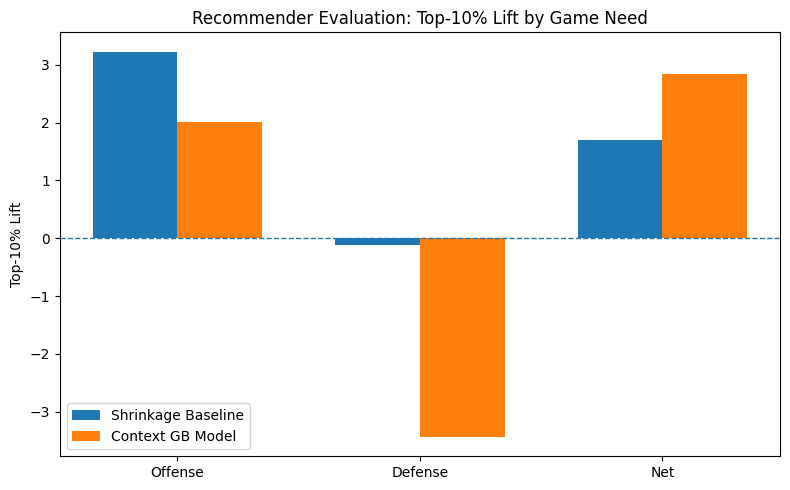

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

lift_plot_df = pd.DataFrame({
    "target": ["Offense", "Defense", "Net"],
    "Shrinkage Baseline": [3.23, -0.12, 1.70],
    "Context GB Model": [2.01, -3.44, 2.85],
})

x = np.arange(len(lift_plot_df["target"]))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, lift_plot_df["Shrinkage Baseline"], width, label="Shrinkage Baseline")
plt.bar(x + width/2, lift_plot_df["Context GB Model"], width, label="Context GB Model")

plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(x, lift_plot_df["target"])
plt.ylabel("Top-10% Lift")
plt.title("Recommender Evaluation: Top-10% Lift by Game Need")
plt.legend()
plt.tight_layout()
plt.show()

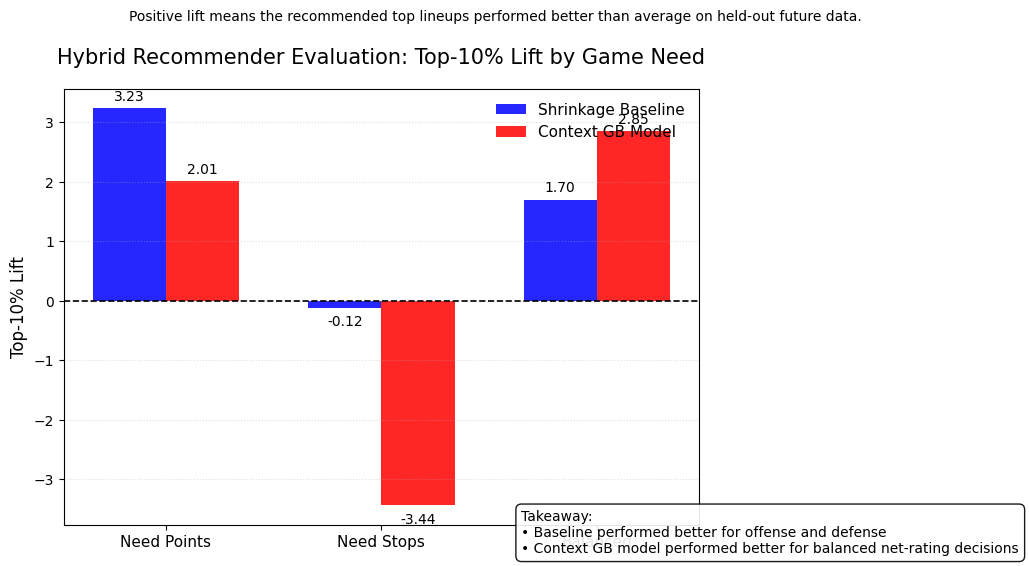

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------
# Data
# ----------------------------------------
lift_plot_df = pd.DataFrame({
    "Game Need": ["Need Points", "Need Stops", "Balanced"],
    "Shrinkage Baseline": [3.23, -0.12, 1.70],
    "Context GB Model": [2.01, -3.44, 2.85],
})

# ----------------------------------------
# Plot settings
# ----------------------------------------
x = np.arange(len(lift_plot_df["Game Need"]))
width = 0.34

fig, ax = plt.subplots(figsize=(10, 6))

baseline_bars = ax.bar(
    x - width/2,
    lift_plot_df["Shrinkage Baseline"],
    width,
    label="Shrinkage Baseline",
    color="blue",
    alpha=0.85
)

model_bars = ax.bar(
    x + width/2,
    lift_plot_df["Context GB Model"],
    width,
    label="Context GB Model",
    color="red",
    alpha=0.85
)

# Zero line
ax.axhline(0, color="black", linewidth=1.2, linestyle="--")

# Axis labels and title
ax.set_xticks(x)
ax.set_xticklabels(lift_plot_df["Game Need"], fontsize=11)
ax.set_ylabel("Top-10% Lift", fontsize=12)
ax.set_title(
    "Hybrid Recommender Evaluation: Top-10% Lift by Game Need",
    fontsize=15,
    pad=18
)

# Optional subtitle
fig.text(
    0.5,
    0.92,
    "Positive lift means the recommended top lineups performed better than average on held-out future data.",
    ha="center",
    fontsize=10
)

# Legend
ax.legend(frameon=False, fontsize=11, loc="upper right")

# Light grid on y-axis
ax.grid(axis="y", linestyle=":", alpha=0.4)

# ----------------------------------------
# Add value labels to bars
# ----------------------------------------
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        x_pos = bar.get_x() + bar.get_width() / 2

        if height >= 0:
            ax.text(
                x_pos,
                height + 0.08,
                f"{height:.2f}",
                ha="center",
                va="bottom",
                fontsize=10
            )
        else:
            ax.text(
                x_pos,
                height - 0.12,
                f"{height:.2f}",
                ha="center",
                va="top",
                fontsize=10
            )

add_labels(baseline_bars)
add_labels(model_bars)

# ----------------------------------------
# Add a short takeaway box inside the figure
# ----------------------------------------
takeaway_text = (
    "Takeaway:\n"
    "• Baseline performed better for offense and defense\n"
    "• Context GB model performed better for balanced net-rating decisions"
)

ax.text(
    1.65,  # x-position in data coordinates
    min(lift_plot_df["Context GB Model"].min(), lift_plot_df["Shrinkage Baseline"].min()) - 0.8,
    takeaway_text,
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9)
)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

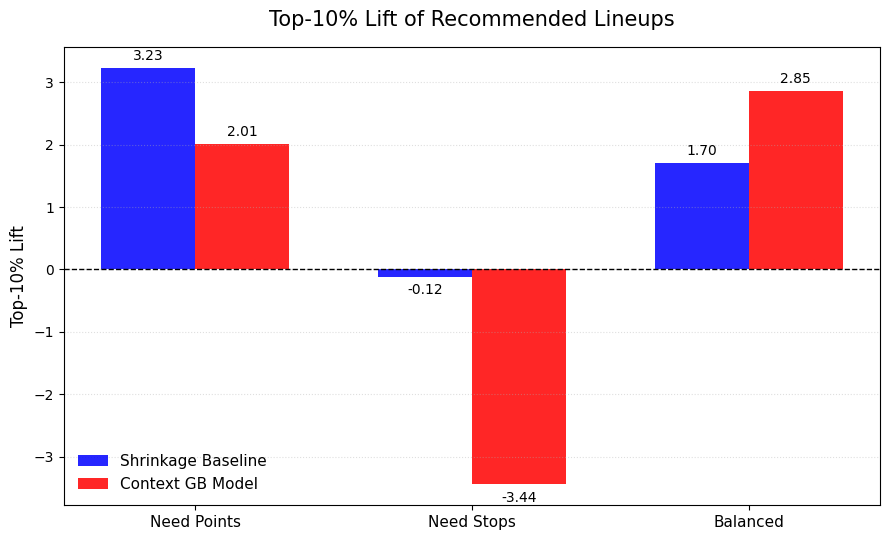

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

lift_plot_df = pd.DataFrame({
    "Game Need": ["Need Points", "Need Stops", "Balanced"],
    "Shrinkage Baseline": [3.23, -0.12, 1.70],
    "Context GB Model": [2.01, -3.44, 2.85],
})

x = np.arange(len(lift_plot_df["Game Need"]))
width = 0.34

fig, ax = plt.subplots(figsize=(9, 5.5))

bars1 = ax.bar(
    x - width/2,
    lift_plot_df["Shrinkage Baseline"],
    width,
    label="Shrinkage Baseline",
    color="blue",
    alpha=0.85
)

bars2 = ax.bar(
    x + width/2,
    lift_plot_df["Context GB Model"],
    width,
    label="Context GB Model",
    color="red",
    alpha=0.85
)

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(lift_plot_df["Game Need"], fontsize=11)
ax.set_ylabel("Top-10% Lift", fontsize=12)
ax.set_title("Top-10% Lift of Recommended Lineups", fontsize=15, pad=15)
ax.legend(frameon=False, fontsize=11)
ax.grid(axis="y", linestyle=":", alpha=0.4)

def label_bars(bars):
    for bar in bars:
        h = bar.get_height()
        if h >= 0:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                h + 0.08,
                f"{h:.2f}",
                ha="center",
                va="bottom",
                fontsize=10
            )
        else:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                h - 0.10,
                f"{h:.2f}",
                ha="center",
                va="top",
                fontsize=10
            )

label_bars(bars1)
label_bars(bars2)

plt.tight_layout()
plt.show()